In [2]:
# Import the libraries.
#
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Global environment.
#

# continent_dict - a dictionary of continents and countries.
#
continent_dict = {'Asia' : ['Afghanistan', 'Armenia', 'Azerbaijan', 'Benin', 'China PR', 'Georgia', 'Guam',
                        'Hong Kong', 'India', 'Indonesia', 'Iran', 'Iraq', 'Israel', 'Japan', 'Jordan',
                        'Kazakhstan', 'Korea DPR', 'Korea Republic', 'Kuwait', 'Lebanon', 'Oman', 'Palestine',
                        'Philippines', 'Qatar', 'Saudi Arabia', 'Syria', 'Thailand', 'Turkey', 'United Arab Emirates',
                        'Uzbekistan'],
            'Europe' : ['Albania', 'Andorra', 'Austria', 'Belarus', 'Belgium', 'Bosnia Herzegovina', 'Bulgaria',
                        'Croatia', 'Cyprus', 'Czech Republic', 'Denmark', 'England', 'Estonia', 'Faroe Islands',
                        'Finland', 'France', 'FYR Macedonia', 'Germany', 'Greece', 'Hungary', 'Iceland', 'Italy', 
                        'Kosovo', 'Latvia', 'Liechtenstein', 'Lithuania', 'Luxembourg', 'Malta', 'Moldova',
                        'Montenegro', 'Montserrat', 'Netherlands', 'Northern Ireland', 'Norway', 'Poland',
                        'Portugal', 'Republic of Ireland', 'Romania', 'Russia', 'Scotland', 'Serbia', 'Slovakia',
                        'Slovenia', 'Spain', 'Sweden', 'Switzerland', 'Ukraine', 'Wales'],
            'Africa' : ['Algeria', 'Angola', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 'Cape Verde',
                        'Central African Rep.', 'Chad', 'Comoros', 'Congo', 'DR Congo', 'Egypt', 'Equatorial Guinea',
                        'Eritrea','Ethiopia', 'Gabon', 'Gambia', 'Ghana','Guinea','Guinea Bissau','Ivory Coast',
                        'Kenya', 'Liberia', 'Libya', 'Madagascar', 'Mali','Mauritania','Mauritius','Morocco',
                        'Mozambique','Namibia','Niger','Nigeria','Senegal','Rwanda','São Tomé & Príncipe',
                        'Sierra Leone','South Africa','South Sudan','Sudan','Tanzania','Togo','Tunisia',
                        'Uganda','Zambia','Zimbabwe'],
            'North America' :  ['Antigua & Barbuda','Barbados','Belize','Bermuda','Canada','Costa Rica',
                                'Cuba','Curacao','Dominican Republic','El Salvador','Grenada','Guatemala','Haiti',
                                'Honduras',	'Jamaica','Mexico','Nicaragua','Panama','Puerto Rico','St Kitts Nevis',
                                'St Lucia',	'Trinidad & Tobago','United States'],
            'South America' :  ['Argentina','Bolivia','Brazil','Chile','Colombia','Ecuador','Guyana','Paraguay',
                                'Peru','Suriname','Uruguay','Venezuela'],
            'Oceania': ['Australia','Fiji','New Caledonia','New Zealand'] }


# fifa_class
#
# This class contains the attributes and methods for analyzing the FIFA data set.
#
class fifa_class:
    
    # Constructor.
    #
    def __init__(self, filename):
        
        # Set the attributes.
        #
        self.filename = filename
        self.country_dict = {}
    
    
    # load_data
    #
    def load_data(self):
        
        # Read in the CSV file.
        #
        self.df = pd.read_csv(self.filename)
        print ("The CSV dataset file,", self.filename, "has been loaded.")
        
        # Create a dictionary of countries->continents based on the
        # continents->countries dictionary.
        #
        for continent in continent_dict:
            
            for country in continent_dict[continent]:
                
                # Set the country as the key and the continent as the value.
                #
                self.country_dict[country] = continent
        
    
    # identify_incomplete_column_data
    #
    def identify_incomplete_column_data(self):
        
        # Print out the columns with null values along with how many records
        # are null for each column.
        #
        pd.options.display.min_rows = 200

        print ('----------------------------')
        print (self.df.isnull().sum().sort_values(ascending=False))
        print ('----------------------------')

        
    # Getter.
    #
    def get_dataframe(self):
        
        return self.df
    
    
    # describe_dataframe
    #
    def describe_dataframe(self):
        
        print(self.df.describe())
        
        
    # create_bins
    #
    def create_bins(self):
     
        # Create the bins.
        #
        self.create_age_group()
        self.create_overall_group()
        self.create_continent()
        
        print("The Age Group, Overall Group and Continent column bins have been created.")
        
        
    # create_age_group
    #
    def create_age_group(self):
     
        # Create a new Age Group bin based on the Age column.
        #
        self.df.loc[self.df['Age'] < 20, "Age Group"] = 'Teenager'
        self.df.loc[(self.df['Age'] >= 20) & (self.df['Age'] < 24), "Age Group"] = 'Early Twenties'
        self.df.loc[(self.df['Age'] >= 24) & (self.df['Age'] < 27), "Age Group"] = 'Mid Twenties'
        self.df.loc[(self.df['Age'] >= 27) & (self.df['Age'] < 30), "Age Group"] = 'Late Twenties'
        self.df.loc[(self.df['Age'] >= 30) & (self.df['Age'] < 34), "Age Group"] = 'Early Thirties'
        self.df.loc[(self.df['Age'] >= 34) & (self.df['Age'] < 37), "Age Group"] = 'Mid Thirties'
        self.df.loc[(self.df['Age'] >= 37) & (self.df['Age'] < 40), "Age Group"] = 'Late Thirties'
        self.df.loc[self.df['Age'] >= 40, "Age Group"] = 'Forties and older'

        
    # create_overall_group
    #
    def create_overall_group(self):
     
        # Create a new Overall Group bin based on the Overall column.
        #
        self.df.loc[self.df['Overall'] < 50, "Overall Group"] = 'Mediocre'
        self.df.loc[(self.df['Overall'] >= 50) & (self.df['Overall'] < 60), "Overall Group"] = 'Average'
        self.df.loc[(self.df['Overall'] >= 60) & (self.df['Overall'] < 70), "Overall Group"] = 'Good'
        self.df.loc[(self.df['Overall'] >= 70) & (self.df['Overall'] < 80), "Overall Group"] = 'Great'
        self.df.loc[(self.df['Overall'] >= 80) & (self.df['Overall'] < 90), "Overall Group"] = 'Excellent'
        self.df.loc[self.df['Overall'] >= 90, "Overall Group"] = 'Elite'

        
    # create_continent
    #
    def create_continent(self):

        # Create a new Continent column based on mapping the player's nationality 
        # to the country / continent dictionary.
        #
        self.df['Continent'] = self.df['Nationality'].map(self.country_dict)
        
        
    # convert_wages
    #
    def convert_wages(self):

        # Create a temporary dataframe to split off the Euros (€) and thousands (K) symbols.
        #
        tdf = self.df['Wage'].str.split('€', expand=True).rename(columns = {1:'Salary-temp'})
        tdf = tdf['Salary-temp'].str.split('K', expand=True).rename(columns = {0:'Salary'})
        
        # Concatenate the main dataframe with the Salary dataframe.
        #
        self.df = pd.concat([self.df, tdf], axis=1)
        
        # How to get rid of that '1' column?
        #
        #self.df.drop(columns='1')

        # Change the new Salary column from an object to an int for analysis.
        #
        self.df = self.df.assign(Salary=self.df['Salary'].astype('int'))
            
        print("The Salary column has been created as an integer.")
        
        
    # fill_empty_data_with_mean
    #
    def fill_empty_data_with_mean(self, column):
        
        # Compute the mean of the column.
        #
        column_mean = self.df[column].mean()

        # Fill all NaNs with the column mean.
        #
        self.df[column] = self.df[column].fillna(column_mean)
        
        print('Empty data in the column,', column, 'has been replaced with the mean:', column_mean)

            
    # pivot_by_columns_and_agg
    #
    def pivot_by_columns_and_agg(self, group_args, pivot_column, agg_arg):
        
        # Create a pivot table based on the group arguments, pivot column and the
        # aggregate arguments (e.g., mean, count).
        #
        p_df = (self.df.pivot_table(index=group_args, values=pivot_column, aggfunc=agg_arg).
                sort_values(by=pivot_column, ascending=False)
               )

        print ('Conducting a', agg_arg, 'on', group_args, 'pivoting on', pivot_column)
        print ('----------------------------')
        print (p_df)
        print ('----------------------------\n')
        
        # Plot a barchart of the top 10 entries of the dataframe.
        #
        self.plot_barchart(p_df.head(10))   
        
    
    # group_by_columns_and_agg
    #
    def group_by_columns_and_agg(self, group_args, agg_column, agg_arg):
 
        # Create a grouping based on the group arguments, aggregate column and the
        # aggregate arguments (e.g., mean, count).
        #
        p_df = (self.df.groupby(by=group_args).agg({agg_column : agg_arg}).
                sort_values(by=agg_column, ascending=False)
               )
                

        print ('Conducting a', agg_arg, 'on', agg_column, 'for the group', group_args)
        print ('----------------------------')
        print (p_df)
        print ('----------------------------\n')
        
        # Plot a barchart of the top 10 entries of the dataframe.
        #
        self.plot_barchart(p_df.head(10))   

        
    # plot_barchart
    #
    def plot_barchart(self, df):

        # Plot the dataframe as a bar chart.
        #
        ax = df.plot.bar(figsize=(20,10), rot=0)

        
    # plot_scatter_plot
    #
    def plot_scatter_plot(self, plot_title, df, column_x, column_y, colour_column):
        
        # Plot the scatter plot using Seaborn and the specified dataframe, x and y
        # columns and separate by values in the colour_column.
        #
        sns.lmplot(x = column_x, y = column_y, data = df, hue=colour_column).set(title=plot_title)

        # Now plot the same scatter plot except don't separate by values in the colour_column
        # to plot an aggregate between all data regardless of the column on which to base
        # the colour (e.g., species name).
        #
        sns.lmplot(x = column_x, y = column_y, data = df).set(title=plot_title)
 
        # Display the scatter plot.
        #
        plt.show()        

        
    # plot_scatter_matrix
    #
    def plot_scatter_matrix(self, df):
    
        # Plot the bar graph by mean.
        #
        pd.plotting.scatter_matrix(df, alpha=0.2, figsize=(10,10))


In [3]:
# Main
#

# Create the object, load and prepare the data.
#
# Note: the data set for this project is from Kaggle:
#
#     https://www.kaggle.com/datasets/mukeshmanral/fifa-data-for-eda-and-stats
# 
my_fifa = fifa_class("fifa_eda_stats.csv")
my_fifa.load_data()
my_fifa.create_bins()
my_fifa.convert_wages()



The CSV dataset file, fifa_eda_stats.csv has been loaded.
The Age Group, Overall Group and Continent column bins have been created.
The Salary column has been created as an integer.


In [4]:
# Identify columns that have empty data.
#
my_fifa.identify_incomplete_column_data()


----------------------------
Loaned From                 16943
Release Clause               1564
Joined                       1553
Contract Valid Until          289
1                             241
Club                          241
Position                       60
Jersey Number                  60
GKDiving                       48
SlidingTackle                  48
Agility                        48
Reactions                      48
Balance                        48
ShotPower                      48
Jumping                        48
Stamina                        48
Strength                       48
LongShots                      48
Aggression                     48
Interceptions                  48
Positioning                    48
GKReflexes                     48
GKPositioning                  48
GKKicking                      48
Acceleration                   48
GKHandling                     48
Vision                         48
Penalties                      48
Composure          

In [5]:
# Fill empty data in the column with the mean of the column.
#
# Perhaps this can be replaced by calculating the mean of the Age Group or
# Overall Group the player is in.
#
my_fifa.fill_empty_data_with_mean('Acceleration')
my_fifa.fill_empty_data_with_mean('Agility')
my_fifa.fill_empty_data_with_mean('Reactions')
my_fifa.fill_empty_data_with_mean('Balance')

Empty data in the column, Acceleration has been replaced with the mean: 64.61407566495953
Empty data in the column, Agility has been replaced with the mean: 63.503607026818656
Empty data in the column, Reactions has been replaced with the mean: 61.83660994548158
Empty data in the column, Balance has been replaced with the mean: 63.966573049176716


In [6]:
# Print some information regarding the data set.
#
my_fifa.describe_dataframe()

                  ID           Age       Overall     Potential  \
count   18207.000000  18207.000000  18207.000000  18207.000000   
mean   214298.338606     25.122206     66.238699     71.307299   
std     29965.244204      4.669943      6.908930      6.136496   
min        16.000000     16.000000     46.000000     48.000000   
25%    200315.500000     21.000000     62.000000     67.000000   
50%    221759.000000     25.000000     66.000000     71.000000   
75%    236529.500000     28.000000     71.000000     75.000000   
max    246620.000000     45.000000     94.000000     95.000000   

       International Reputation     Weak Foot   Skill Moves  Jersey Number  \
count              18159.000000  18159.000000  18159.000000   18147.000000   
mean                   1.113222      2.947299      2.361308      19.546096   
std                    0.394031      0.660456      0.756164      15.947765   
min                    1.000000      1.000000      1.000000       1.000000   
25%            

Conducting a max on Age for the group ['Age Group']
----------------------------
                   Age
Age Group             
Forties and older   45
Late Thirties       39
Mid Thirties        36
Early Thirties      33
Late Twenties       29
Mid Twenties        26
Early Twenties      23
Teenager            19
----------------------------



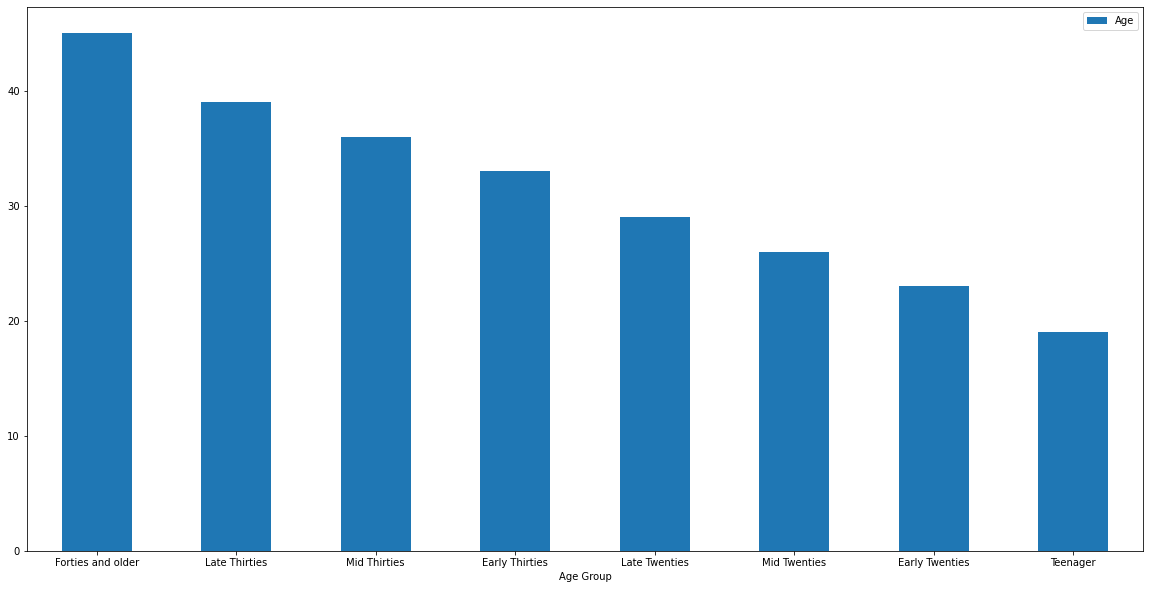

In [12]:
# Transferred
#
# Count the number of players in each Age Group.
#
my_fifa.group_by_columns_and_agg(['Age Group'], 'Age', 'max')


In [ ]:
# Transferred
#
# Count the number of players from each Continent.
#
my_fifa.group_by_columns_and_agg(['Continent'], 'Name', 'count')


In [ ]:
# Transferred
#

# Count how many players are in each Overall skill category.
#
my_fifa.group_by_columns_and_agg(['Overall Group'], 'Name', 'count')

# This would make a good distribution graph as it appears to follow a normal distribution.
#

In [ ]:
# Transferred
#
# Count how many players are in each category per continent.
#
my_fifa.group_by_columns_and_agg(['Continent', 'Overall Group'], 'Name', 'count')


Conducting a mean on ['Continent', 'Overall Group'] pivoting on Salary
----------------------------
                                 Salary
Continent     Overall Group            
South America Elite          358.750000
Europe        Elite          309.900000
Africa        Excellent       86.933333
South America Excellent       86.517544
Europe        Excellent       81.321990
Asia          Excellent       76.714286
North America Excellent       62.375000
Europe        Great           19.139085
Africa        Great           18.370690
Asia          Great           17.754789
North America Great           15.944444
Oceania       Great           15.823529
South America Great           15.121451
North America Good             3.761062
Africa        Good             3.613312
Europe        Good             3.585918
Asia          Good             3.367154
South America Good             2.993477
Oceania       Good             2.294479
Asia          Average          1.610915
North America Averag

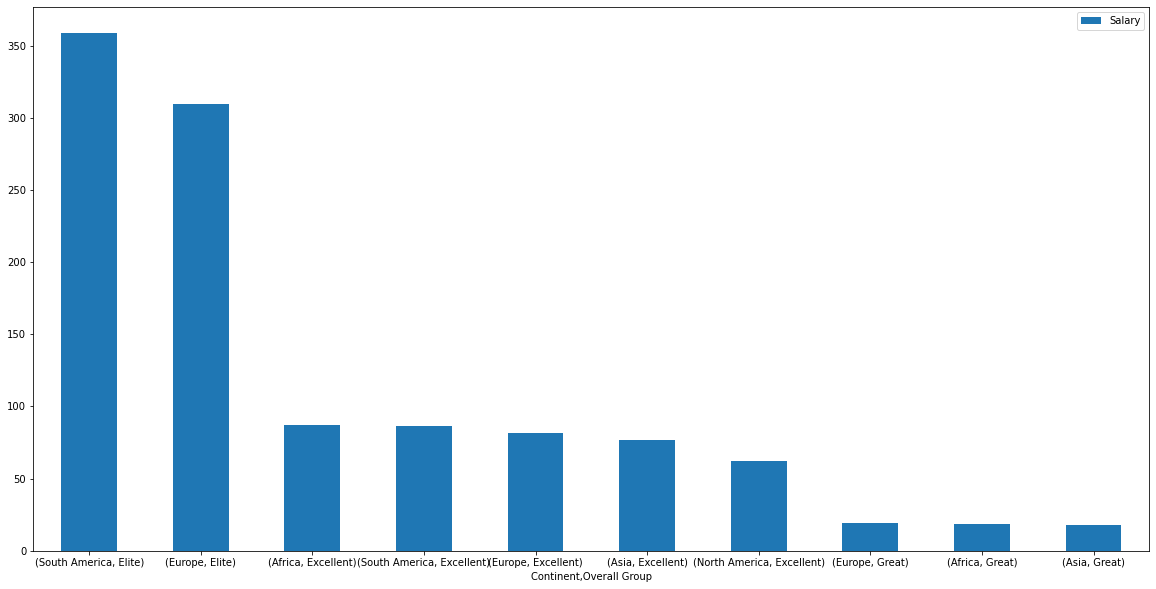

In [8]:
# Calculate the salaries by Continent and Overall group.
#
my_fifa.pivot_by_columns_and_agg(['Continent', 'Overall Group'], 'Salary', 'mean')


Conducting a count on ['Overall Group', 'Age Group'] pivoting on Name
----------------------------
                                 Name
Overall Group Age Group              
Good          Early Twenties     3080
              Mid Twenties       2365
              Late Twenties      1719
Great         Mid Twenties       1309
Good          Early Thirties     1295
Great         Late Twenties      1255
Average       Early Twenties     1213
              Teenager           1167
Great         Early Thirties     1112
              Early Twenties      955
Good          Teenager            761
              Mid Thirties        379
Great         Mid Thirties        294
Average       Mid Twenties        237
Excellent     Mid Twenties        151
              Late Twenties       145
              Early Thirties      136
Average       Late Twenties        98
Great         Teenager             82
Mediocre      Teenager             73
Excellent     Early Twenties       73
Great         Late Thirties

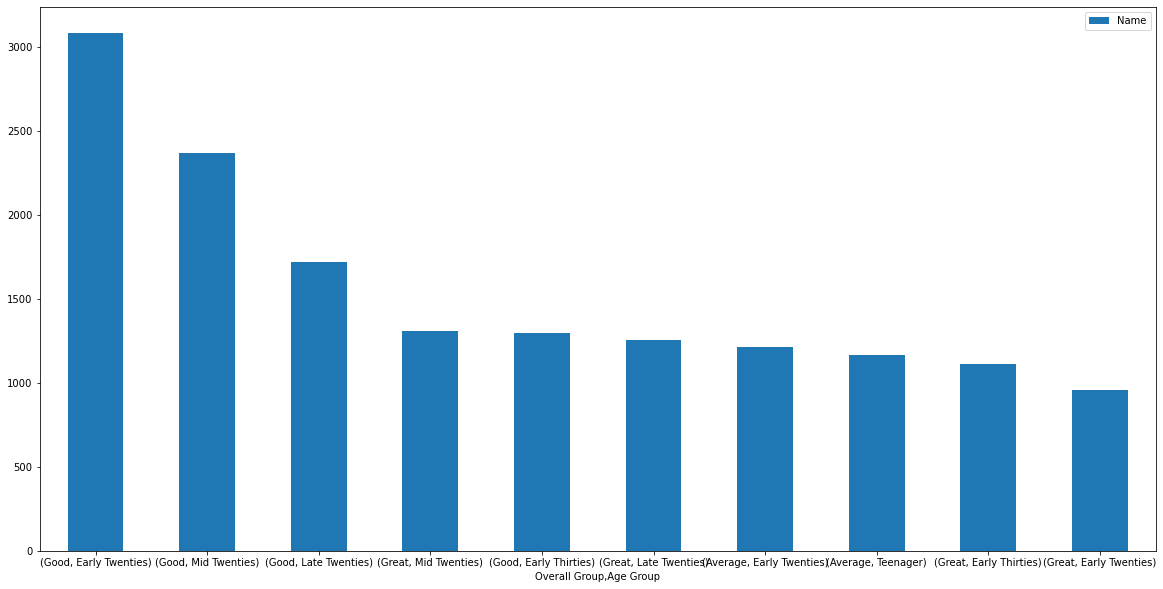

In [9]:
# Count the number of players per Overall Group and Age Group,
#
my_fifa.pivot_by_columns_and_agg(['Overall Group', 'Age Group'], 'Name', 'count')


Conducting a min on ['Age Group'] pivoting on Age
----------------------------
                   Age
Age Group             
Forties and older   40
Late Thirties       37
Mid Thirties        34
Early Thirties      30
Late Twenties       27
Mid Twenties        24
Early Twenties      20
Teenager            16
----------------------------



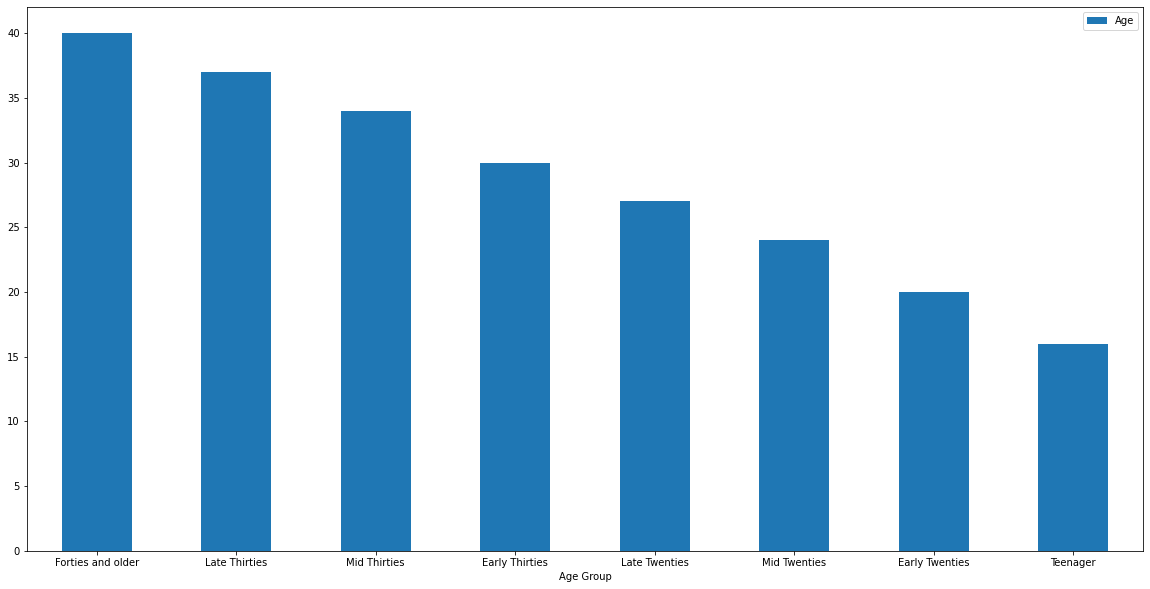

In [15]:
# Calculate the average age per continent.
#
my_fifa.pivot_by_columns_and_agg(['Age Group'], 'Age', 'min')


Conducting a count on Name for the group ['Continent', 'Age Group', 'Overall Group']
----------------------------
                                               Name
Continent     Age Group         Overall Group      
Europe        Early Twenties    Good           1926
              Mid Twenties      Good           1302
              Late Twenties     Good            927
              Teenager          Average         834
              Mid Twenties      Great           723
              Late Twenties     Great           720
              Early Thirties    Good            716
              Early Twenties    Average         640
                                Great           599
              Early Thirties    Great           582
              Teenager          Good            520
South America Early Twenties    Good            462
              Mid Twenties      Good            409
              Early Thirties    Great           319
Asia          Mid Twenties      Good            313
So

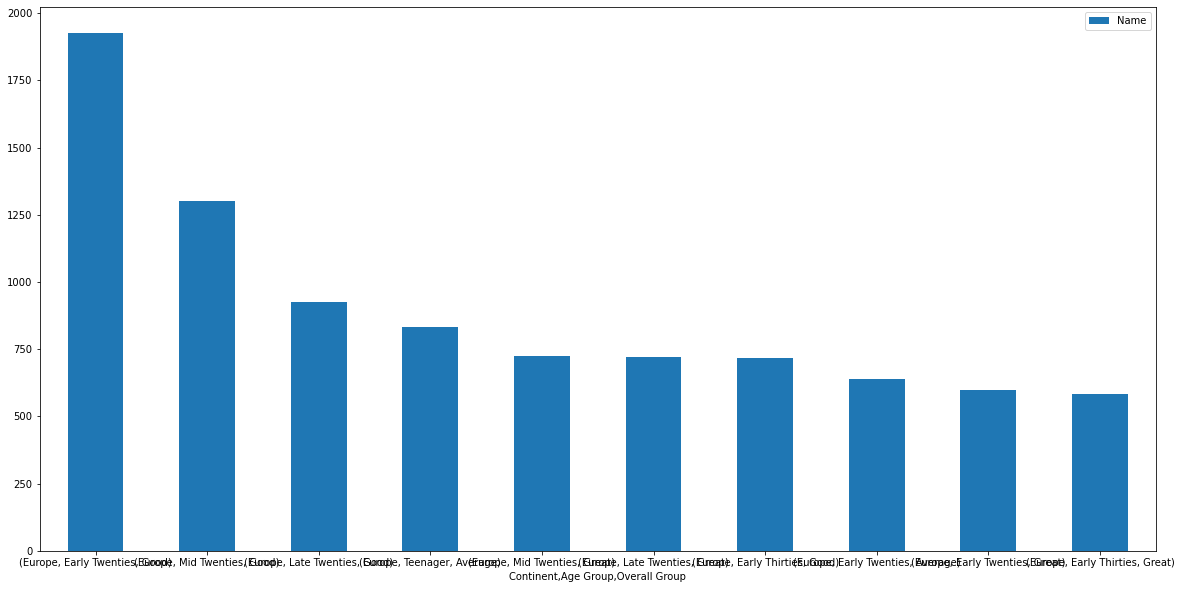

In [11]:
# Count the number of players by Continent, Age Group and Overall group.
#
my_fifa.group_by_columns_and_agg(['Continent', 'Age Group', 'Overall Group'], 'Name', 'count')


Conducting a mean on ['Continent', 'Overall Group'] pivoting on Salary
----------------------------
                                 Salary
Continent     Overall Group            
South America Elite          358.750000
Europe        Elite          309.900000
Africa        Excellent       86.933333
South America Excellent       86.517544
Europe        Excellent       81.321990
Asia          Excellent       76.714286
North America Excellent       62.375000
Europe        Great           19.139085
Africa        Great           18.370690
Asia          Great           17.754789
North America Great           15.944444
Oceania       Great           15.823529
South America Great           15.121451
North America Good             3.761062
Africa        Good             3.613312
Europe        Good             3.585918
Asia          Good             3.367154
South America Good             2.993477
Oceania       Good             2.294479
Asia          Average          1.610915
North America Averag

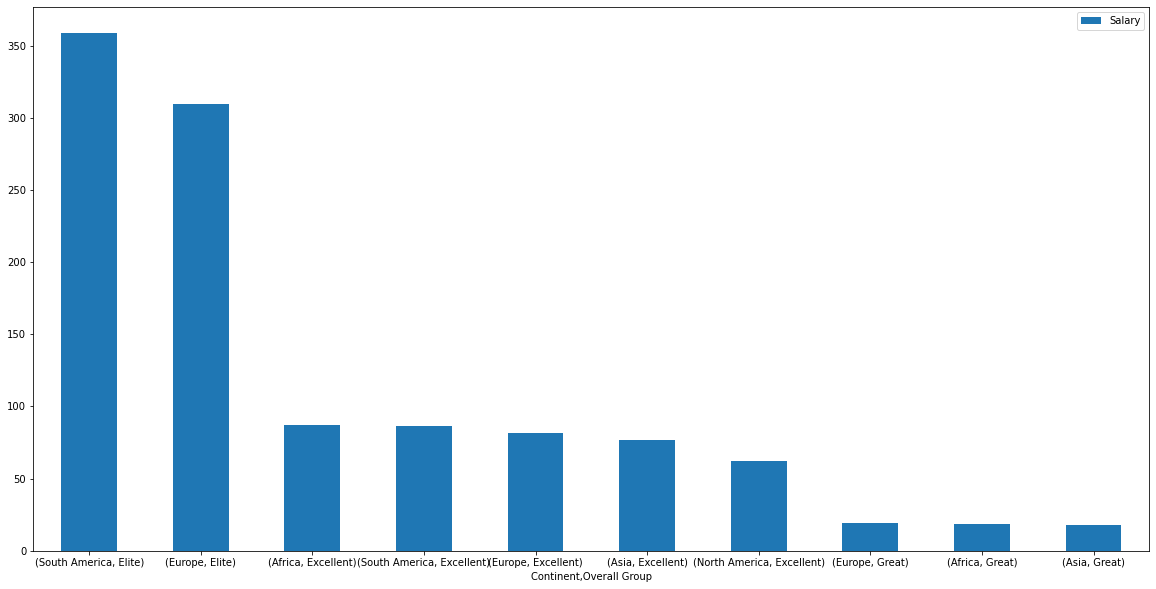

In [16]:
# Transferred
#

# Get the maximum salary by Continent and Overall Group.
#
my_fifa.pivot_by_columns_and_agg(['Continent', 'Overall Group'], 'Salary', 'mean')

# Observation: not surprisingly, the higher the player rating, the more salary that is 
# typically made.  Average and mediocre players are at the lower end of the scale.
#

Conducting a mean on ['Age Group'] pivoting on Salary
----------------------------
                      Salary
Age Group                   
Early Thirties     14.219493
Late Twenties      13.841403
Mid Twenties       11.358760
Mid Thirties        8.894085
Early Twenties      6.890347
Forties and older   6.318182
Late Thirties       6.076389
Teenager            2.454720
----------------------------



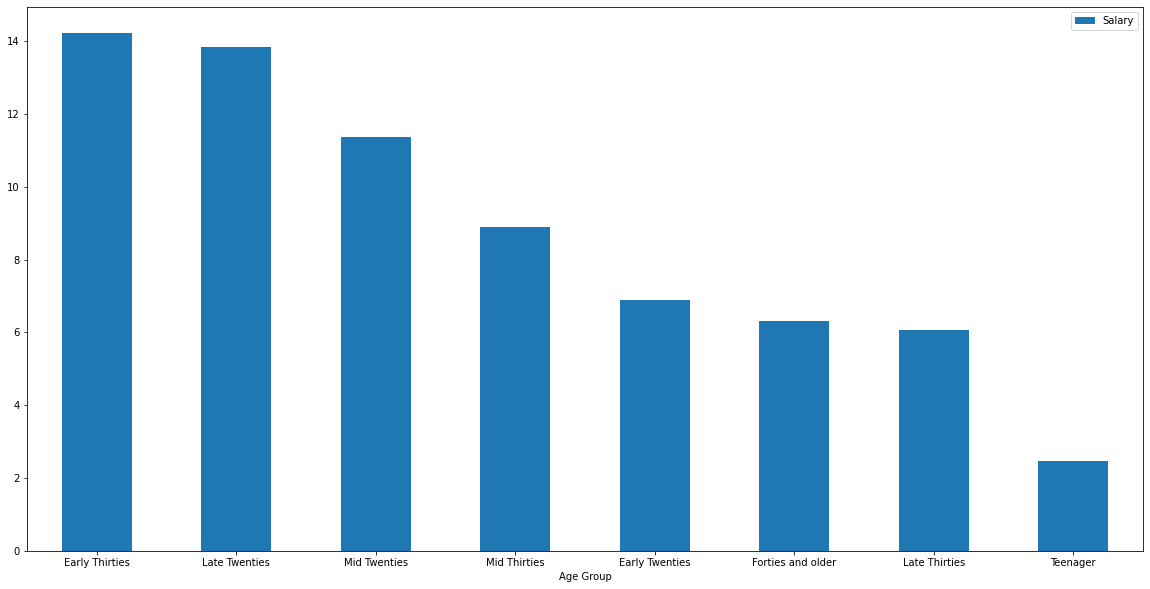

In [13]:
# Transferred
#

# Get the maximum salary by Continent and Age Group.
#
#my_fifa.pivot_by_columns_and_agg(['Continent', 'Age Group'], 'Salary', 'max')
my_fifa.pivot_by_columns_and_agg(['Age Group'], 'Salary', 'mean')

# Observation: not surprisingly, maximum salary is from the mid-twenties to early-thirties.
# Teenagers and late-thirties and older are at the lower end of the scale.
#

Conducting a mean on BallControl for the group ['Overall Group', 'Age Group']
----------------------------
                                 BallControl
Overall Group Age Group                     
Elite         Early Thirties       89.571429
              Late Twenties        81.200000
Excellent     Early Twenties       77.246575
              Mid Twenties         75.046358
              Late Twenties        73.186207
              Early Thirties       70.500000
Great         Teenager             70.024390
              Early Twenties       69.214660
Excellent     Mid Thirties         68.925926
              Teenager             68.750000
Great         Mid Twenties         67.227655
              Late Twenties        66.341036
              Early Thirties       64.565647
Good          Teenager             59.571429
Great         Mid Thirties         59.459184
Good          Early Twenties       58.081513
              Mid Twenties         57.864681
Mediocre      Early Thirties       57.

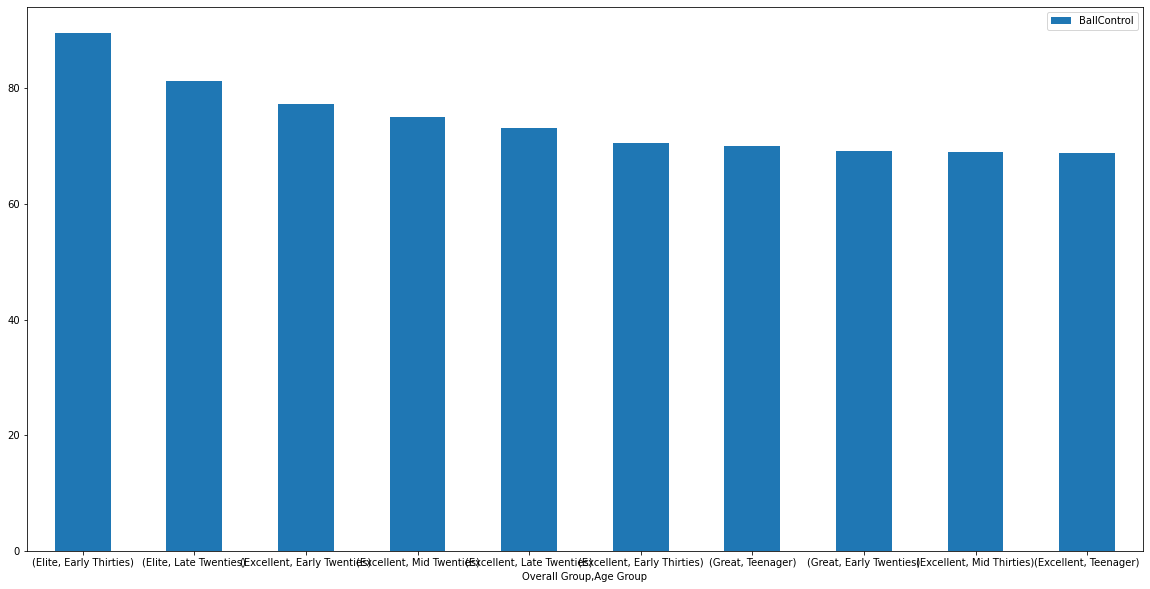

In [16]:
# Get the average Ball Control based on Overall Group and Age Group,
#
my_fifa.group_by_columns_and_agg(['Overall Group', 'Age Group'], 'BallControl', 'mean')


Conducting a mean on Stamina for the group ['Overall Group', 'Age Group']
----------------------------
                                   Stamina
Overall Group Age Group                   
Elite         Early Thirties     81.000000
Excellent     Early Twenties     75.616438
              Late Twenties      74.351724
              Mid Twenties       73.801325
Elite         Late Twenties      73.800000
Great         Late Twenties      70.773705
              Mid Twenties       70.759358
              Early Twenties     70.078534
              Teenager           69.158537
Excellent     Early Thirties     69.132353
Great         Early Thirties     66.723921
Excellent     Teenager           66.000000
Good          Late Twenties      65.681287
              Mid Twenties       65.620000
              Early Thirties     63.944272
              Early Twenties     62.466580
Excellent     Mid Thirties       61.111111
Elite         Mid Twenties       61.000000
Good          Teenager           59.0

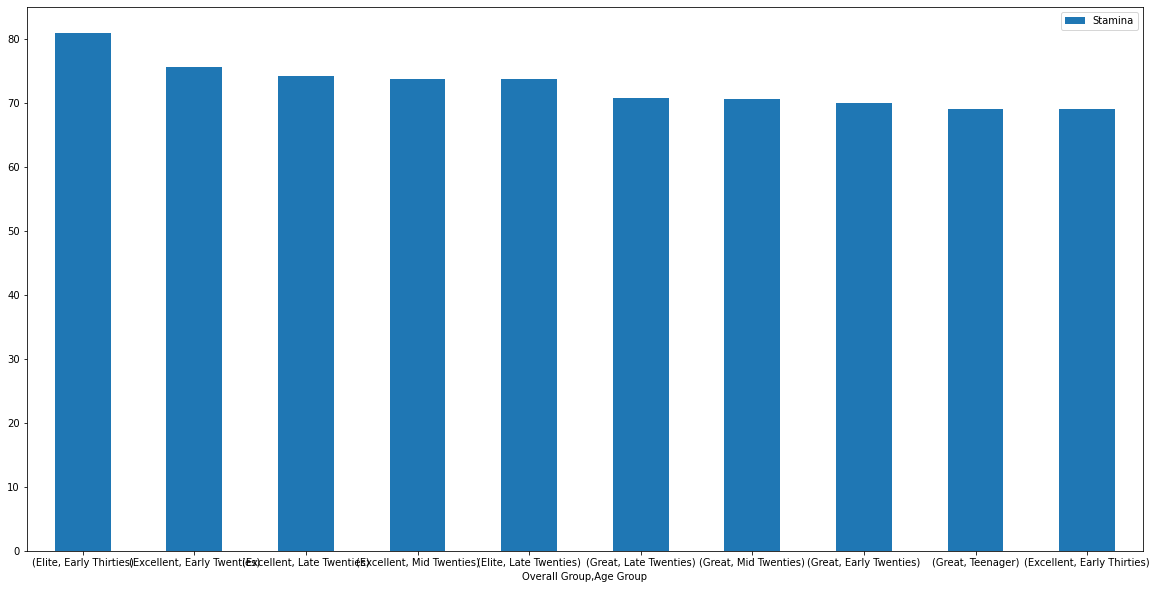

In [17]:
# Get the average Ball Control based on Overall Group and Age Group,
#
my_fifa.group_by_columns_and_agg(['Overall Group', 'Age Group'], 'Stamina', 'mean')


Conducting a count on Name for the group ['Overall Group', 'Body Type']
----------------------------
                                   Name
Overall Group Body Type                
Good          Normal               5699
              Lean                 3314
Great         Normal               3070
              Lean                 1614
Average       Normal               1484
              Lean                 1233
Good          Stocky                603
Great         Stocky                399
Excellent     Normal                299
              Lean                  202
Average       Stocky                 98
Mediocre      Lean                   51
Excellent     Stocky                 37
Mediocre      Normal                 35
Elite         Normal                  8
Mediocre      Stocky                  3
Elite         Lean                    3
Good          Akinfenwa               1
Excellent     PLAYER_BODY_TYPE_25     1
              Courtois                1
Elite         Neyma

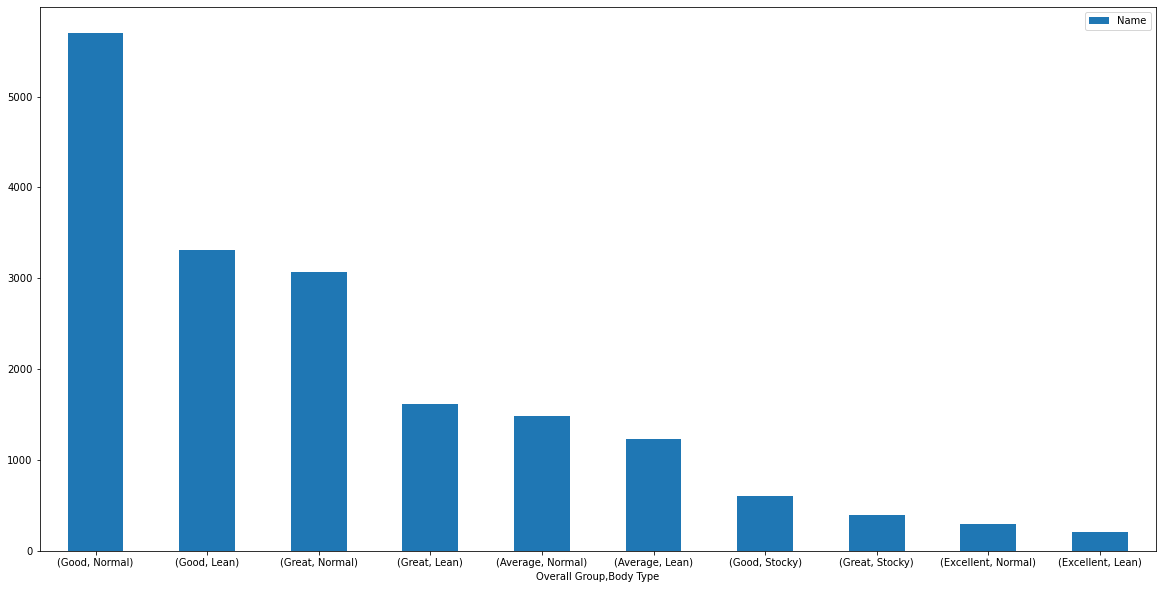

In [18]:
# Get the average Ball Control based on Overall Group and Age Group,
#
my_fifa.group_by_columns_and_agg(['Overall Group', 'Body Type'], 'Name', 'count')


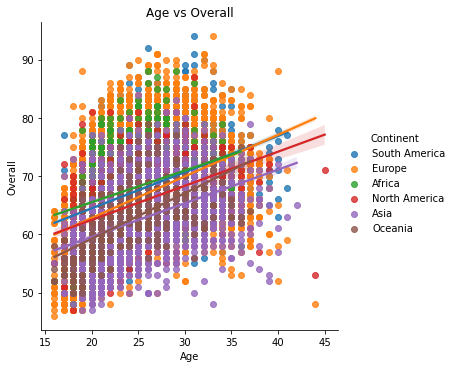

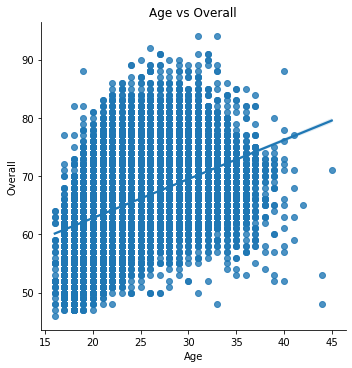

In [19]:
# Plot a scatter plot based on Age and Overall skill level.
#
my_fifa.plot_scatter_plot("Age vs Overall", my_fifa.get_dataframe(), 'Age', 'Overall', 'Continent')

# Observation: Note how well Europe is represented by overall skill level at all ages.
#

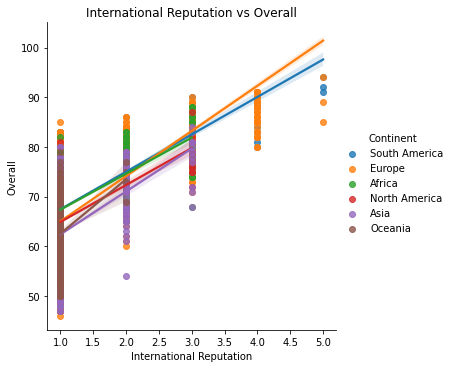

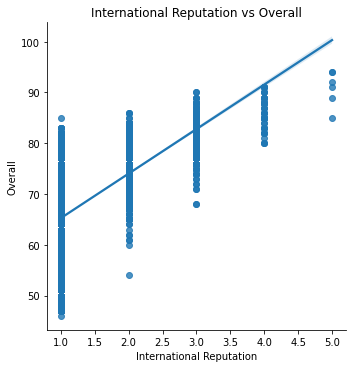

In [20]:
# Plot a scatter plot based on International Reputation and Overall skill level.
#
my_fifa.plot_scatter_plot("International Reputation vs Overall", my_fifa.get_dataframe(), 'International Reputation', 'Overall', 'Continent')

# Observation: Note how well Europe is represented by International Reputation.  The European
# linear relationship line tracks higher than South America.  The other continents don't make
# it past 3.
#

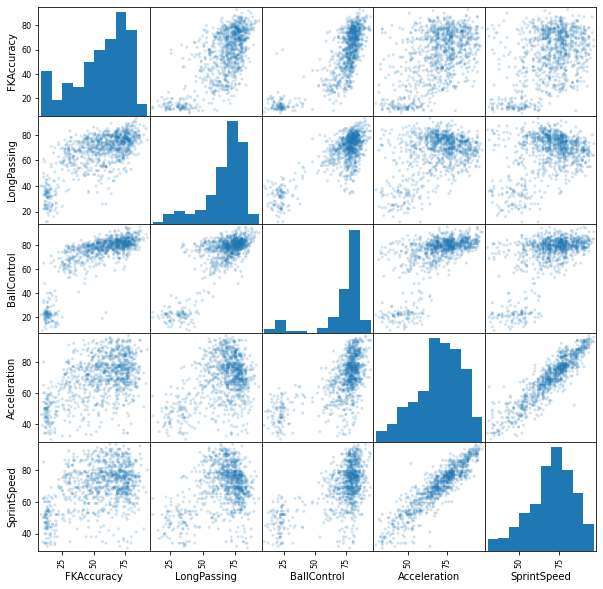

In [21]:
# NEW!!
#

# Plot a scatter matrix of 1000 records from FKAccuracy to SprintSpeed.
#
df = my_fifa.get_dataframe().loc[1:1000, 'FKAccuracy':'SprintSpeed']
my_fifa.plot_scatter_matrix(df)

# Observation: Acceleration and SprintSpeed look like there is a positive correlation.
#              BallControl and LongPassing also look to be positive correlated

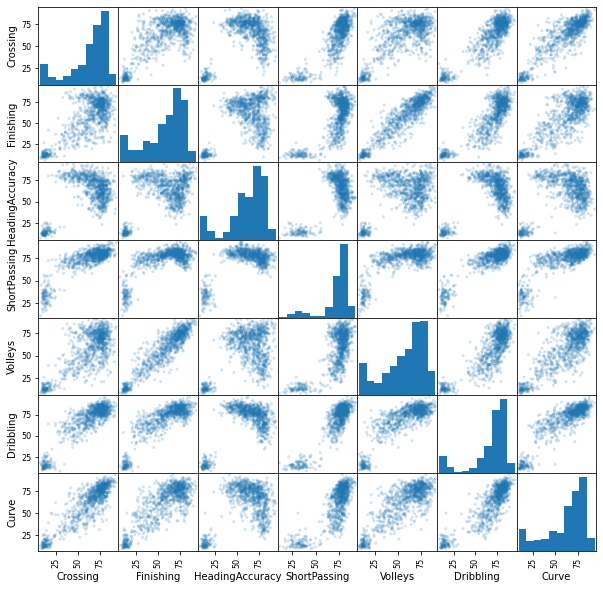

In [22]:
# NEW!!
#

# Plot a scatter matrix of 1000 records from Crossing to Curve.
#
df = my_fifa.get_dataframe().loc[1:1000, 'Crossing':'Curve']
my_fifa.plot_scatter_matrix(df)

# Observation: Finishing and Volleys look like there is a positive correlation.
#              Crossing and Curve also look to be positive correlated

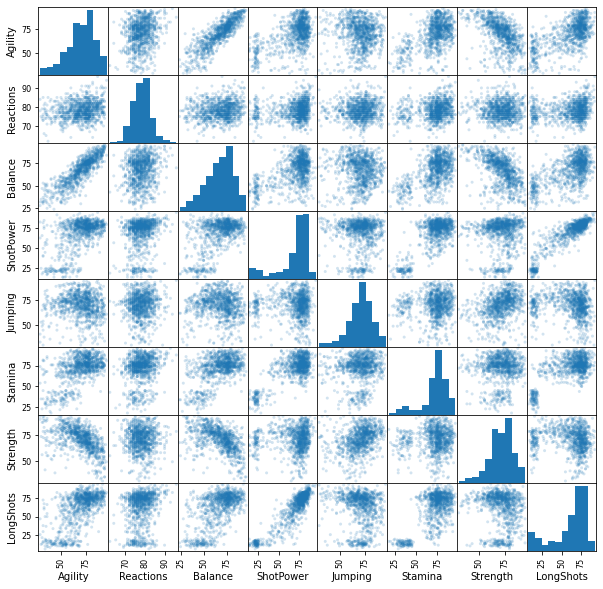

In [23]:
# Plot a scatter matrix of 1000 records from Agility to LongShots.
#
df = my_fifa.get_dataframe().loc[1:1000, 'Agility':'LongShots']
my_fifa.plot_scatter_matrix(df)

# Observation: Agility and Balance look like there is a positive correlation.
#              Longshot and ShotPower also look to be positive correlated

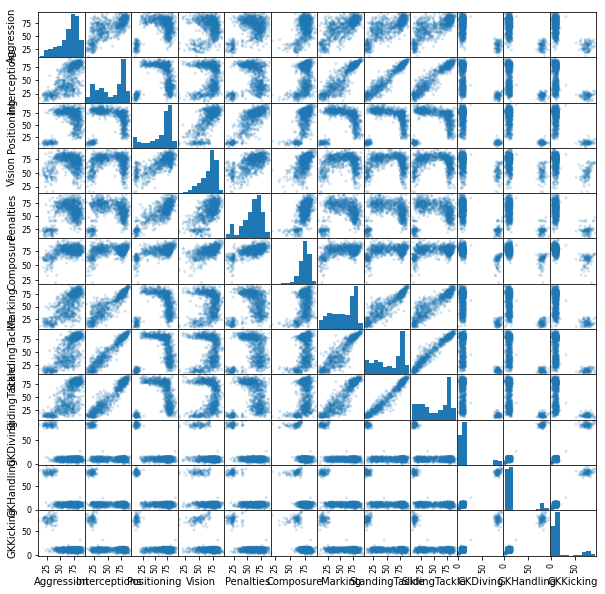

In [24]:
df = my_fifa.get_dataframe().loc[1:1000, 'Aggression':'GKKicking']
my_fifa.plot_scatter_matrix(df)

# Observation: Agility and Balance look like there is a positive correlation.
#              Longshot and ShotPower also look to be positive correlated


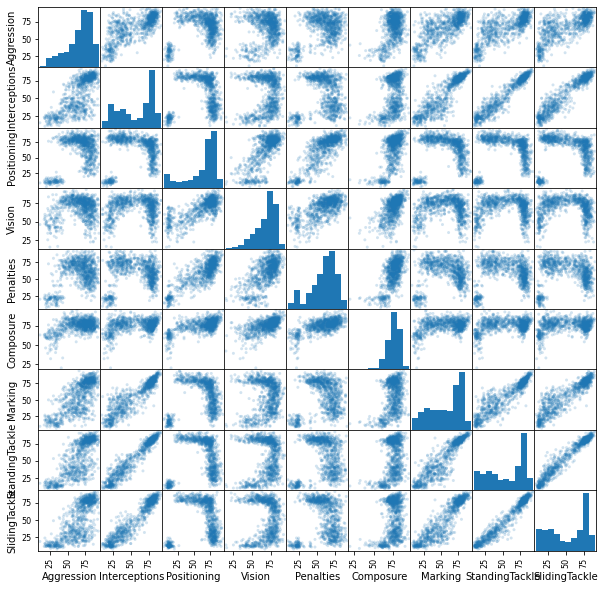

In [25]:
# The same as above except the last three columns don't seem to give us any information.
# Therefore, dropping those columns here.
#
df = my_fifa.get_dataframe().loc[1:1000, 'Aggression':'SlidingTackle']
my_fifa.plot_scatter_matrix(df)

# Observation: Interception and Marking, Standing Tackle and Sliding Tackle look to be
#              positively correlated.


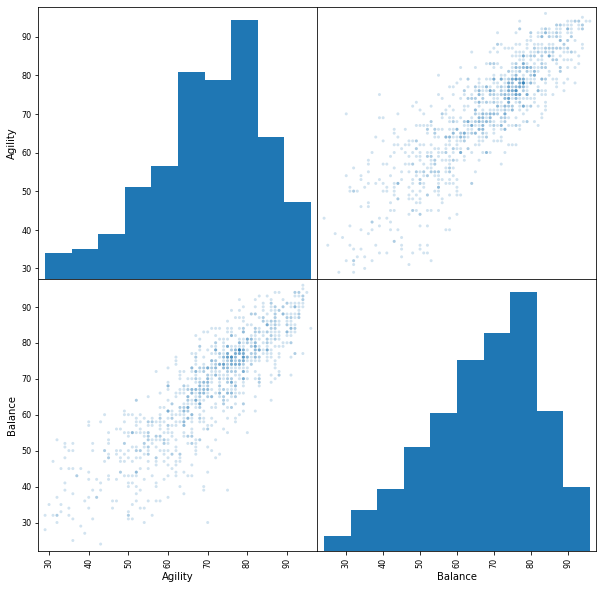

In [26]:
# Plot a scatter matrix of 1000 records using just Agility and Balance.
#
df = my_fifa.get_dataframe().loc[1:1000, ['Agility','Balance']]
my_fifa.plot_scatter_matrix(df)

# Observation: Agility and Balance look like there is a positive correlation.
#

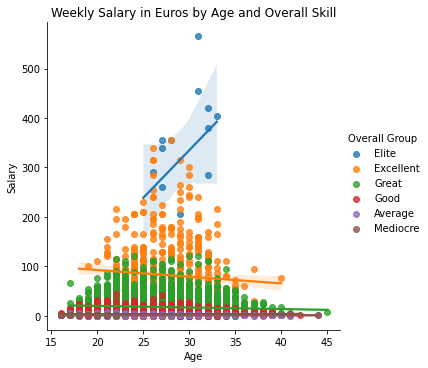

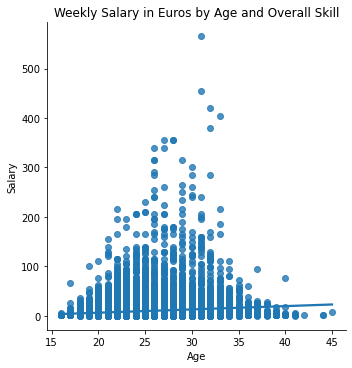

In [21]:
# Plot a scatter plot based on Age and Overall skill level.
#
my_fifa.plot_scatter_plot("Weekly Salary in Euros by Age and Overall Skill", my_fifa.get_dataframe(), 'Age', 'Salary', 'Overall Group')

# Observation: most of the Elite and Excellent players are concentrated in the 25 - 30 age group
# compared to the other types of players where there are more outliers.


Conducting a mean on Weak Foot for the group ['Overall Group']
----------------------------
               Weak Foot
Overall Group           
Elite           3.785714
Excellent       3.280961
Great           3.076530
Good            2.923261
Average         2.735702
Mediocre        2.696629
----------------------------

Conducting a mean on Weak Foot for the group ['Continent', 'Overall Group']
----------------------------
                             Weak Foot
Continent     Overall Group           
Asia          Excellent       4.285714
South America Elite           4.000000
Europe        Elite           3.700000
North America Excellent       3.500000
Europe        Excellent       3.280105
Asia          Great           3.272031
Africa        Excellent       3.233333
South America Excellent       3.219298
Oceania       Great           3.176471
Europe        Great           3.090845
Africa        Great           3.084052
North America Great           3.078704
Africa        Mediocre     

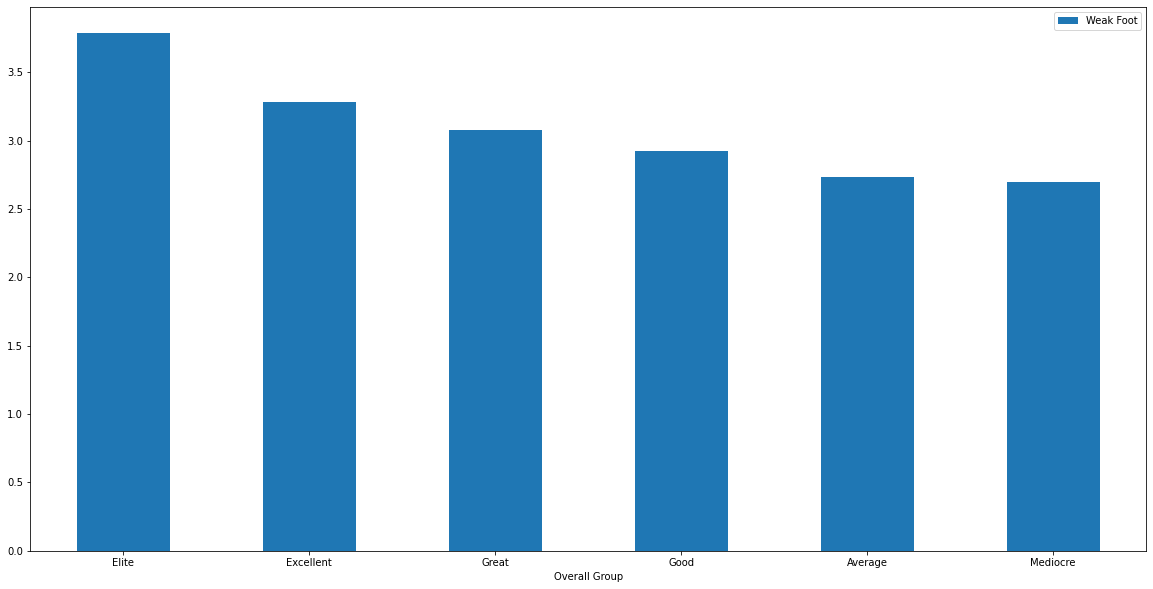

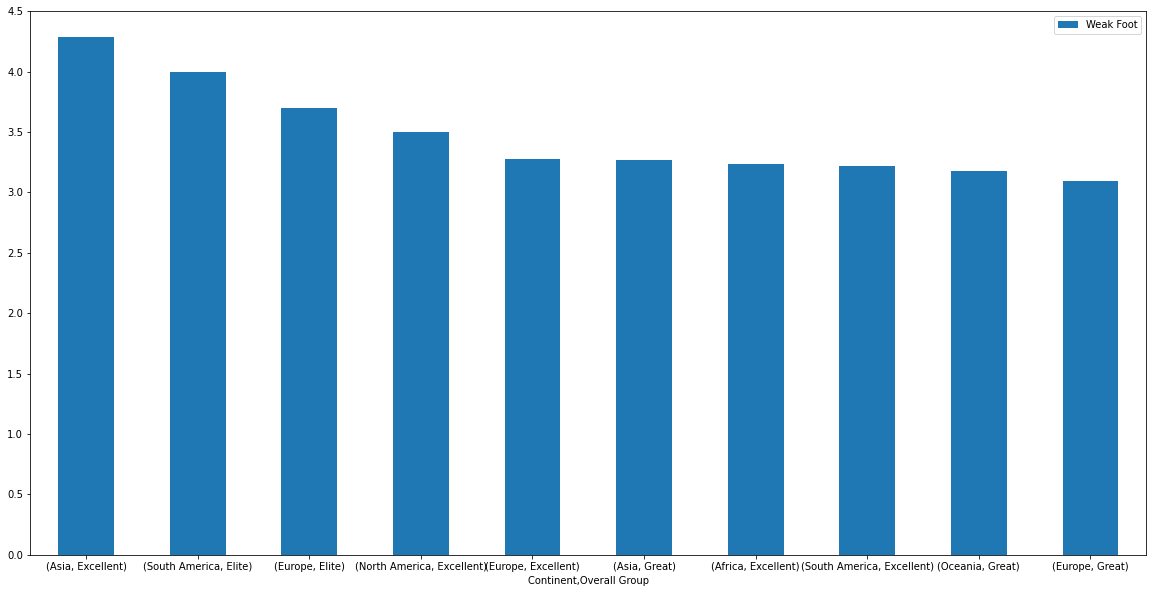

In [28]:
# NEW!!  

# Get the average Ball Control based on Overall Group and Age Group,
#
my_fifa.group_by_columns_and_agg(['Overall Group'], 'Weak Foot', 'mean')
my_fifa.group_by_columns_and_agg(['Continent', 'Overall Group'], 'Weak Foot', 'mean')

# Observation:  The Elite and Excellent players have a higher Weak Foot rating

Conducting a mean on Skill Moves for the group ['Overall Group']
----------------------------
               Skill Moves
Overall Group             
Elite             3.357143
Excellent         3.009242
Great             2.698800
Good              2.286576
Average           1.894494
Mediocre          1.831461
----------------------------

Conducting a mean on Skill Moves for the group ['Continent', 'Overall Group']
----------------------------
                             Skill Moves
Continent     Overall Group             
Asia          Excellent         3.714286
North America Excellent         3.500000
South America Elite             3.500000
Europe        Elite             3.300000
Africa        Excellent         3.233333
South America Excellent         3.157895
Africa        Mediocre          3.000000
Europe        Excellent         2.924084
Africa        Great             2.915948
Asia          Great             2.762452
South America Great             2.719243
Europe        Great 

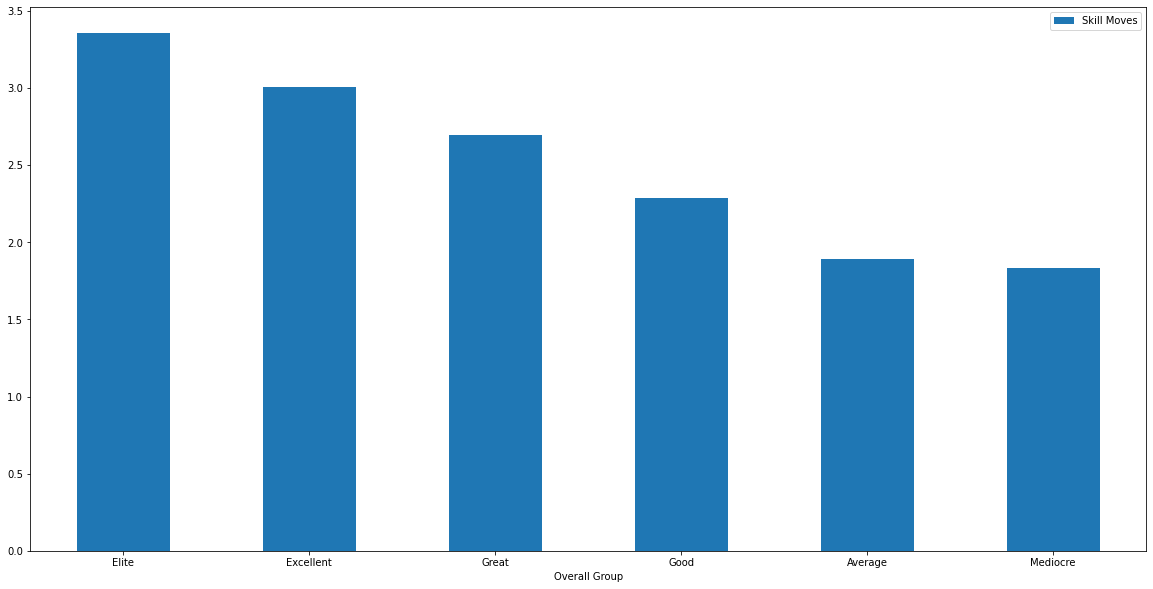

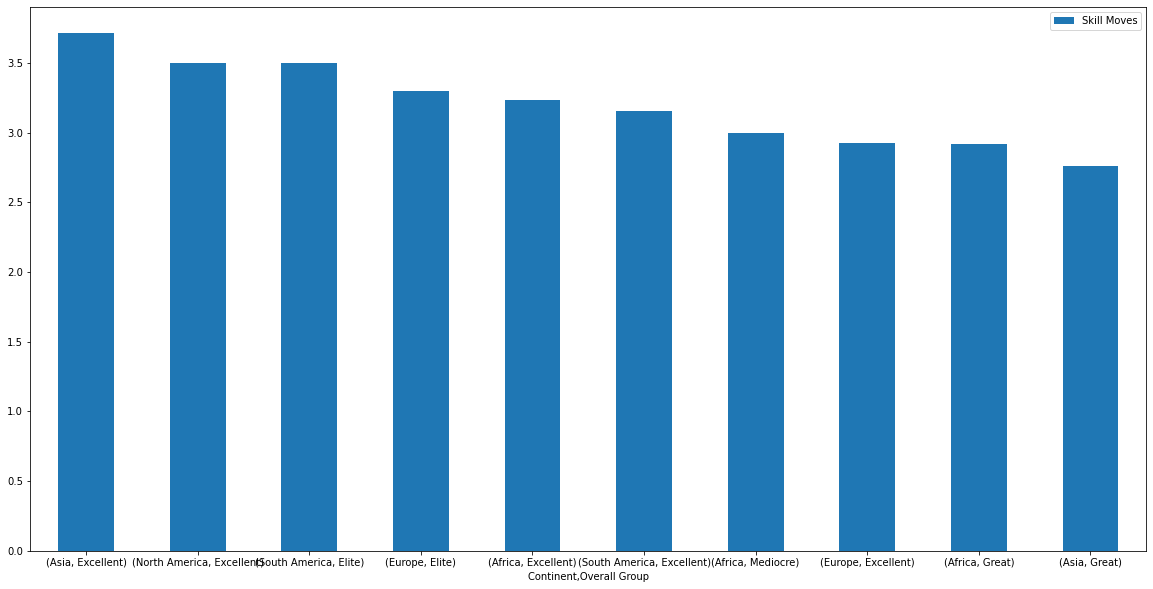

In [29]:
# NEW!!  

# Get the average Skill Moves based on Overall Group and Continent.
#
my_fifa.group_by_columns_and_agg(['Overall Group'], 'Skill Moves', 'mean')
my_fifa.group_by_columns_and_agg(['Continent', 'Overall Group'], 'Skill Moves', 'mean')

# Observation:  The Elite and Excellent players have a higher Skill Moves rating

Conducting a mean on International Reputation for the group ['Overall Group']
----------------------------
               International Reputation
Overall Group                          
Elite                          4.142857
Excellent                      2.454713
Great                          1.221523
Good                           1.010190
Average                        1.000355
Mediocre                       1.000000
----------------------------

Conducting a mean on International Reputation for the group ['Continent', 'Overall Group']
----------------------------
                             International Reputation
Continent     Overall Group                          
South America Elite                          4.500000
Europe        Elite                          4.000000
North America Excellent                      2.500000
Europe        Excellent                      2.476440
South America Excellent                      2.429825
Asia          Excellent                      

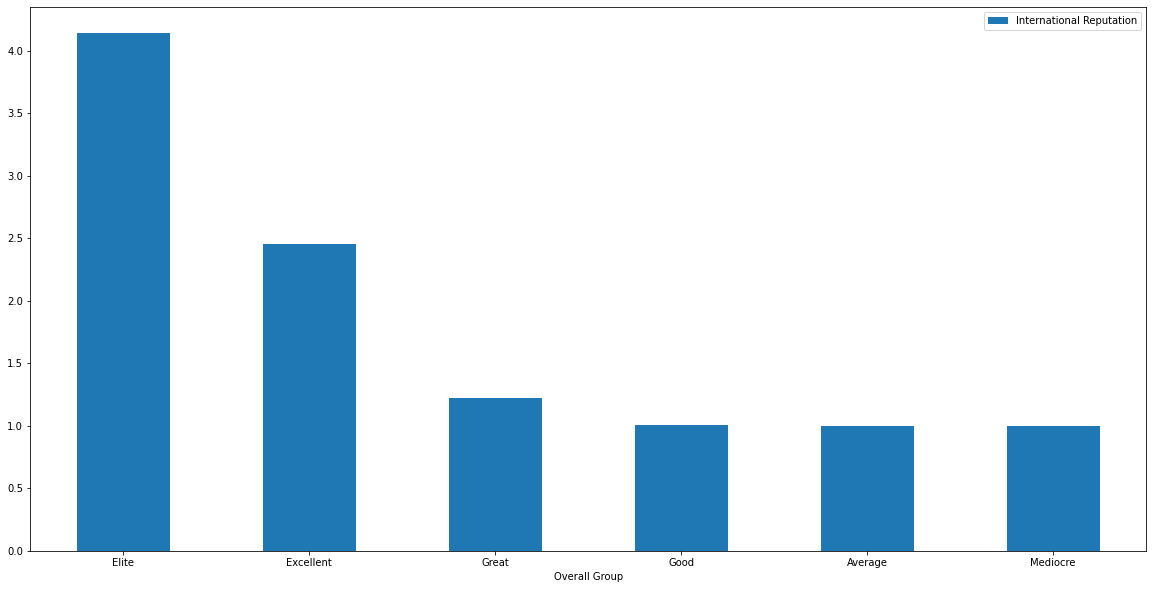

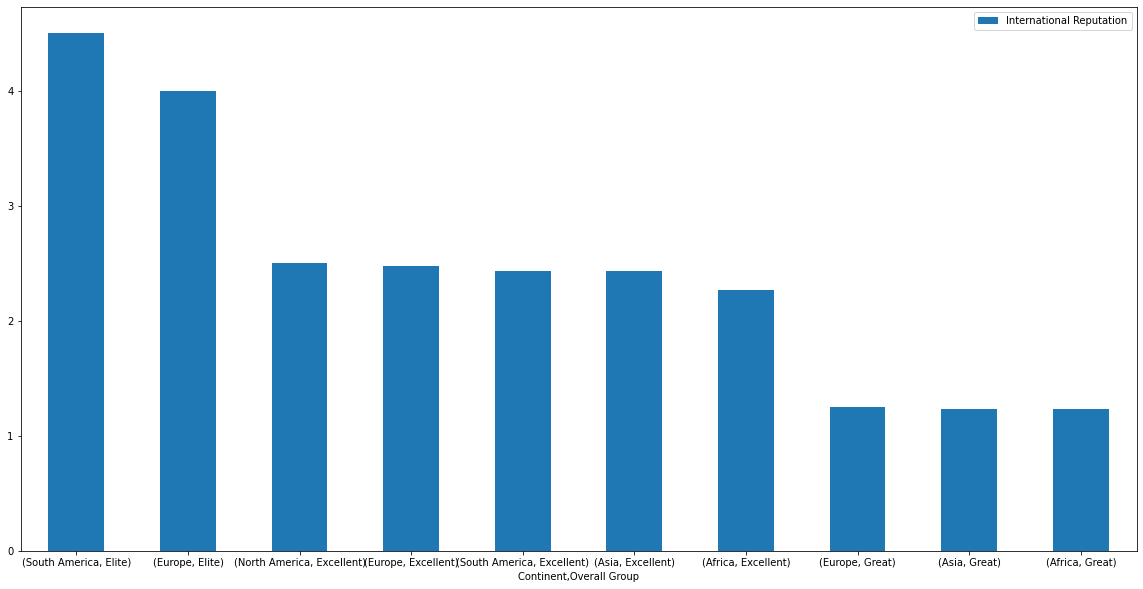

In [30]:
# NEW!!  

# Get the average Skill Moves based on Overall Group and Continent.
#
my_fifa.group_by_columns_and_agg(['Overall Group'], 'International Reputation', 'mean')
my_fifa.group_by_columns_and_agg(['Continent', 'Overall Group'], 'International Reputation', 'mean')

# Observation:  Not suprisingly, the Elite and Excellent players have a higher 
# International Reputation ratings

Conducting a count on Preferred Foot for the group ['Overall Group']
----------------------------
               Preferred Foot
Overall Group                
Good                     9617
Great                    5083
Average                  2815
Excellent                 541
Mediocre                   89
Elite                      14
----------------------------

Conducting a count on Name for the group ['Overall Group', 'Preferred Foot']
----------------------------
                              Name
Overall Group Preferred Foot      
Good          Right           7297
Great         Right           3853
Good          Left            2320
Average       Right           2307
Great         Left            1230
Average       Left             508
Excellent     Right            402
              Left             139
Mediocre      Right             77
Elite         Right             12
Mediocre      Left              12
Elite         Left               2
----------------------------



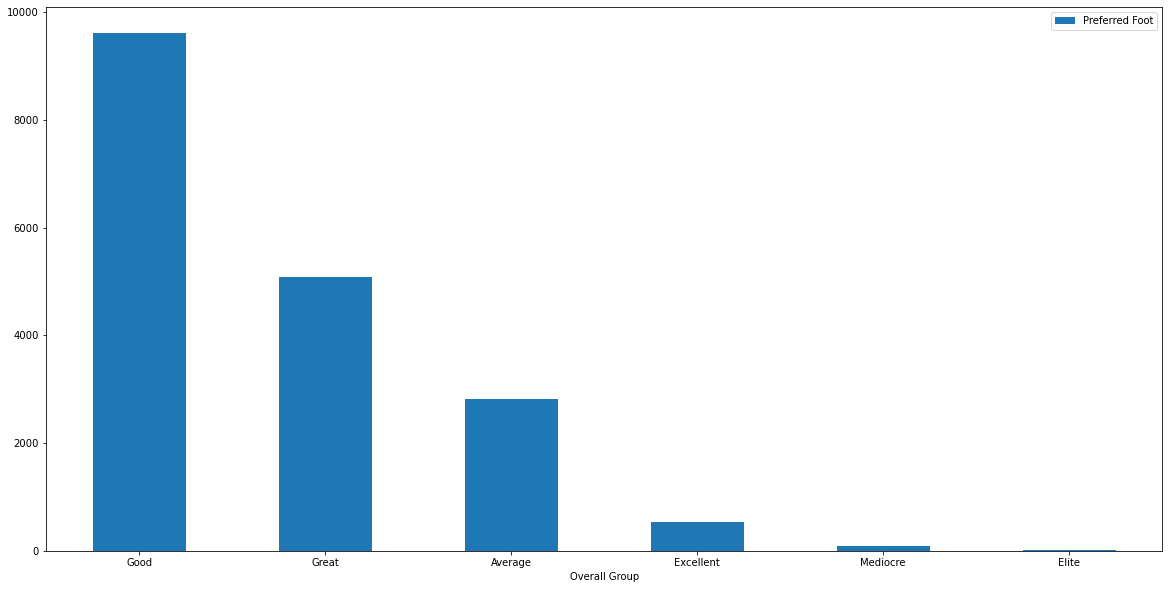

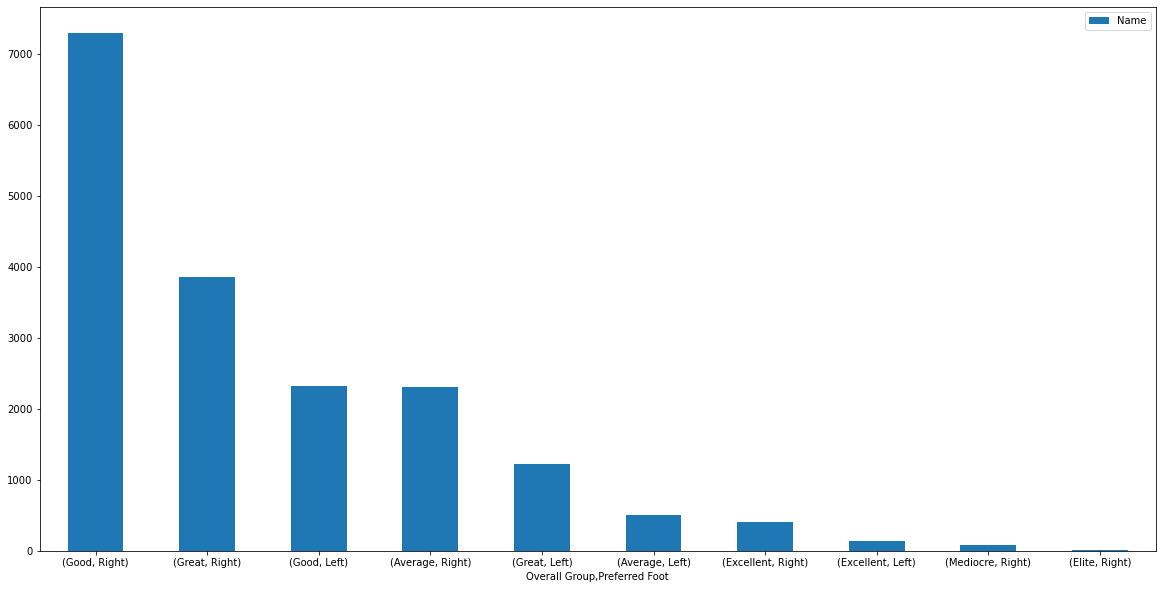

In [31]:
# NEW!!  

# Get the average Skill Moves based on Overall Group and Continent.
#
my_fifa.group_by_columns_and_agg(['Overall Group'], 'Preferred Foot', 'count')
my_fifa.group_by_columns_and_agg(['Overall Group', 'Preferred Foot'], 'Name', 'count')

# Observation:  Preferred Foot doesn't seem to have any bearing as there are Elite and Excellent
# players with both Preferred Foot.

Conducting a count on Overall Group for the group ['Body Type']
----------------------------
                     Overall Group
Body Type                         
Normal                       10595
Lean                          6417
Stocky                        1140
Akinfenwa                        1
C. Ronaldo                       1
Courtois                         1
Messi                            1
Neymar                           1
PLAYER_BODY_TYPE_25              1
Shaqiri                          1
----------------------------

Conducting a count on Name for the group ['Body Type', 'Overall Group']
----------------------------
                                   Name
Body Type           Overall Group      
Normal              Good           5699
Lean                Good           3314
Normal              Great          3070
Lean                Great          1614
Normal              Average        1484
Lean                Average        1233
Stocky              Good            

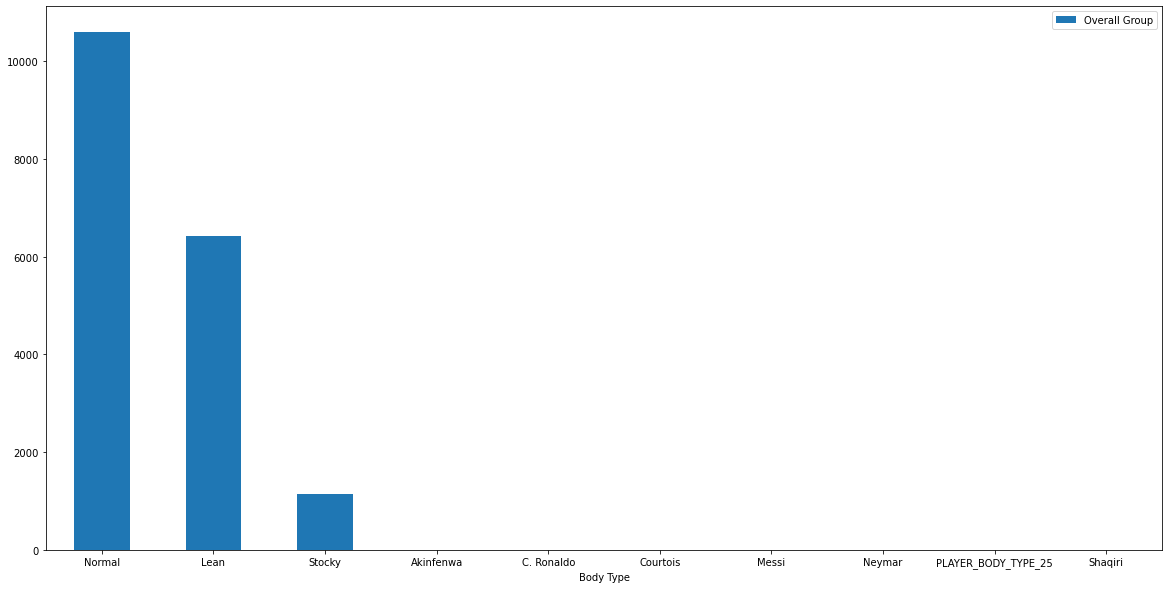

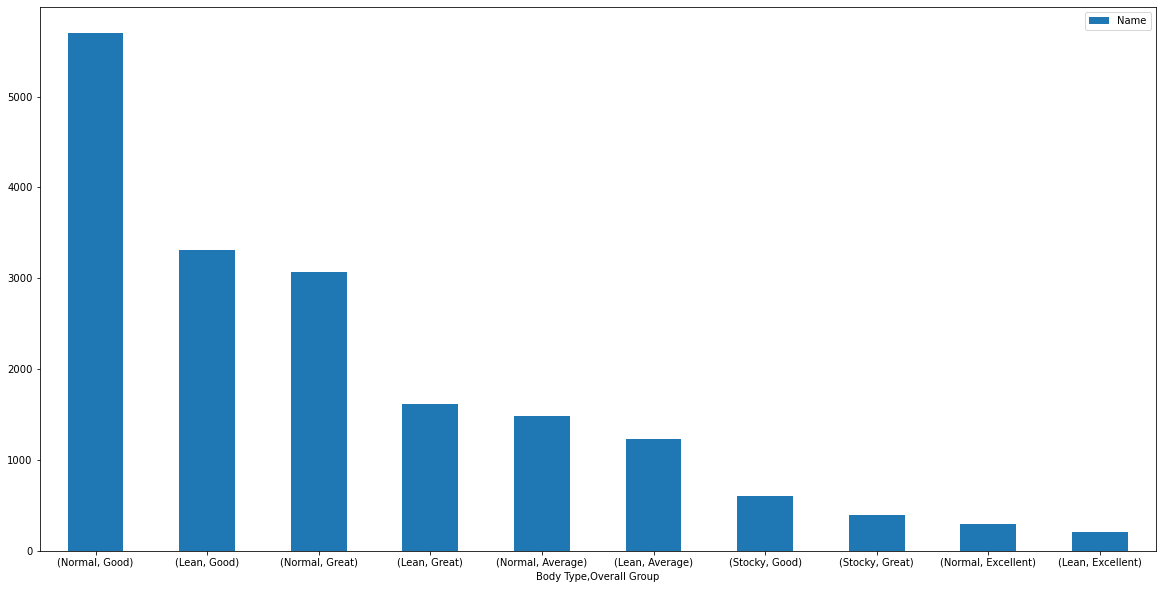

In [32]:
# NEW!!  

# Get the Body Type by Overall Group.
#
my_fifa.group_by_columns_and_agg(['Body Type'], 'Overall Group', 'count')
my_fifa.group_by_columns_and_agg(['Body Type', 'Overall Group'], 'Name', 'count')

# Observation:  Most data is either Normal or Lean so not sure this has any relevance.
#

Conducting a count on Overall Group for the group ['Position']
----------------------------
          Overall Group
Position               
ST                 2152
GK                 2025
CB                 1778
CM                 1394
LB                 1322
RB                 1291
RM                 1124
LM                 1095
CAM                 958
CDM                 948
RCB                 662
LCB                 648
LCM                 395
RCM                 391
LW                  381
RW                  370
RDM                 248
LDM                 243
LS                  207
RS                  203
RWB                  87
LWB                  78
CF                   74
LAM                  21
RAM                  21
RF                   16
LF                   15
----------------------------

Conducting a count on Name for the group ['Position', 'Overall Group']
----------------------------
                        Name
Position Overall Group      
ST       Good           

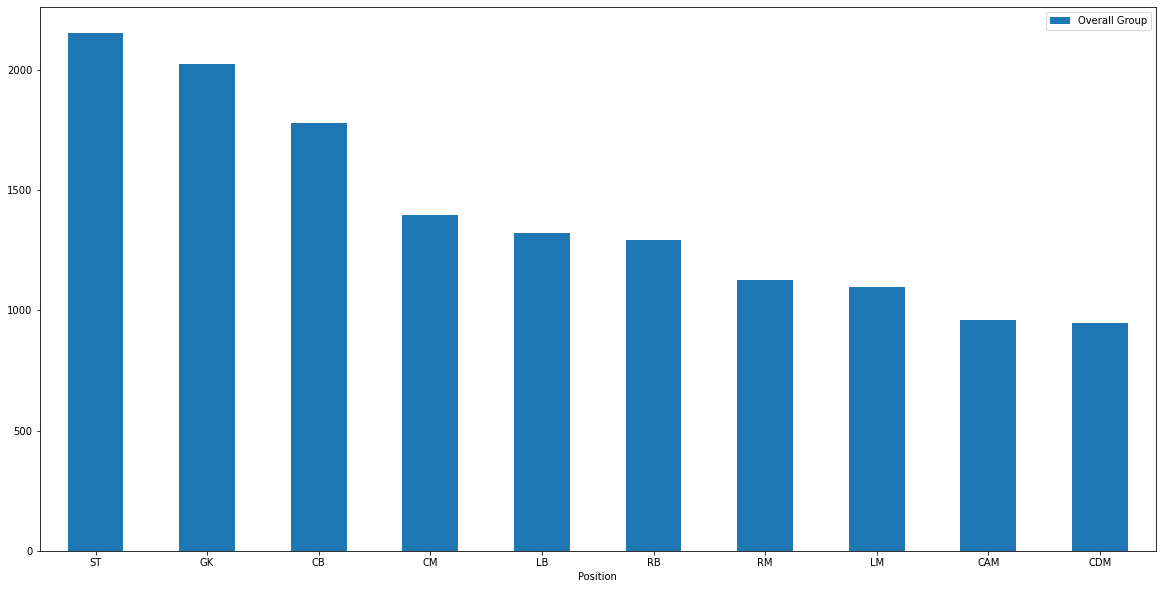

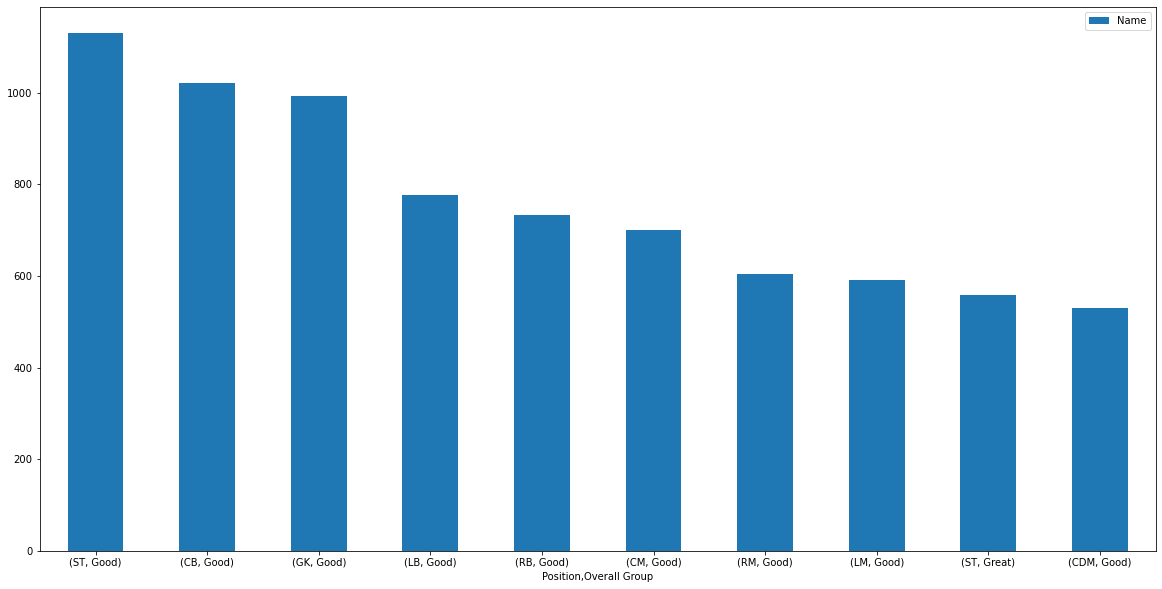

In [33]:
# NEW!!  

# Get the Position by Overall Group.
#
my_fifa.group_by_columns_and_agg(['Position'], 'Overall Group', 'count')
my_fifa.group_by_columns_and_agg(['Position', 'Overall Group'], 'Name', 'count')

# Observation:  Positions and Overall Group are all well represented so not sure 
# this has any relevance.
#

Conducting a mean on Aggression for the group ['Continent']
----------------------------
               Aggression
Continent                
Africa          59.620000
South America   56.711097
Europe          55.934824
North America   55.686296
Oceania         53.709220
Asia            52.332004
----------------------------

Conducting a mean on Aggression for the group ['Overall Group']
----------------------------
               Aggression
Overall Group            
Excellent       66.024030
Elite           63.714286
Great           63.235688
Good            55.004367
Average         43.983659
Mediocre        41.528090
----------------------------

Conducting a mean on Aggression for the group ['Continent', 'Overall Group']
----------------------------
                             Aggression
Continent     Overall Group            
Africa        Excellent       72.866667
South America Elite           70.000000
              Excellent       69.561404
Africa        Great           64.780

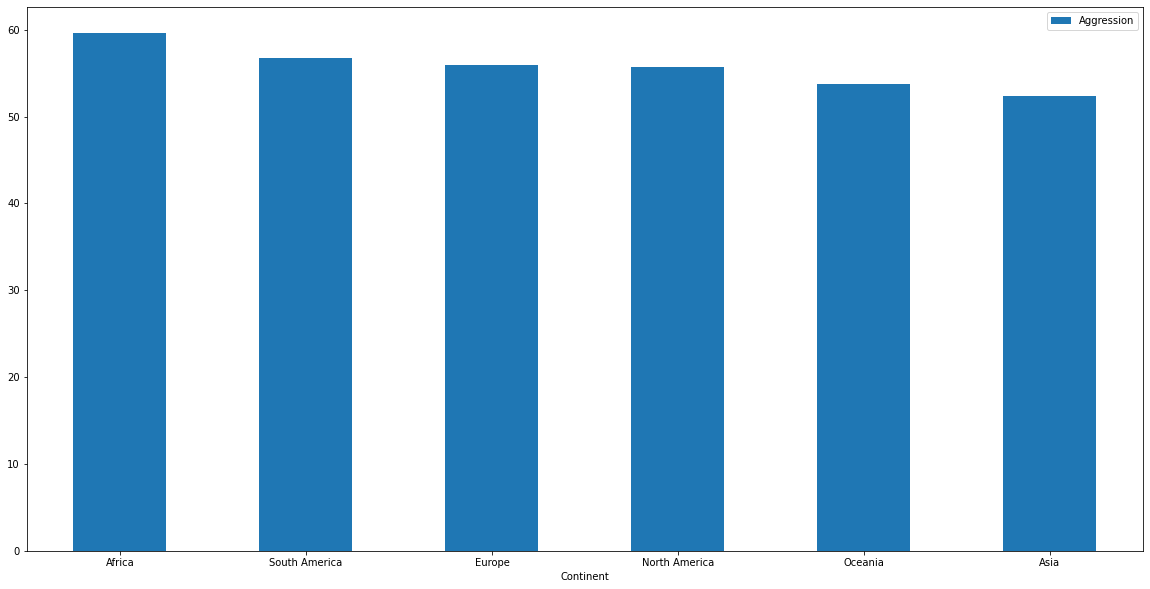

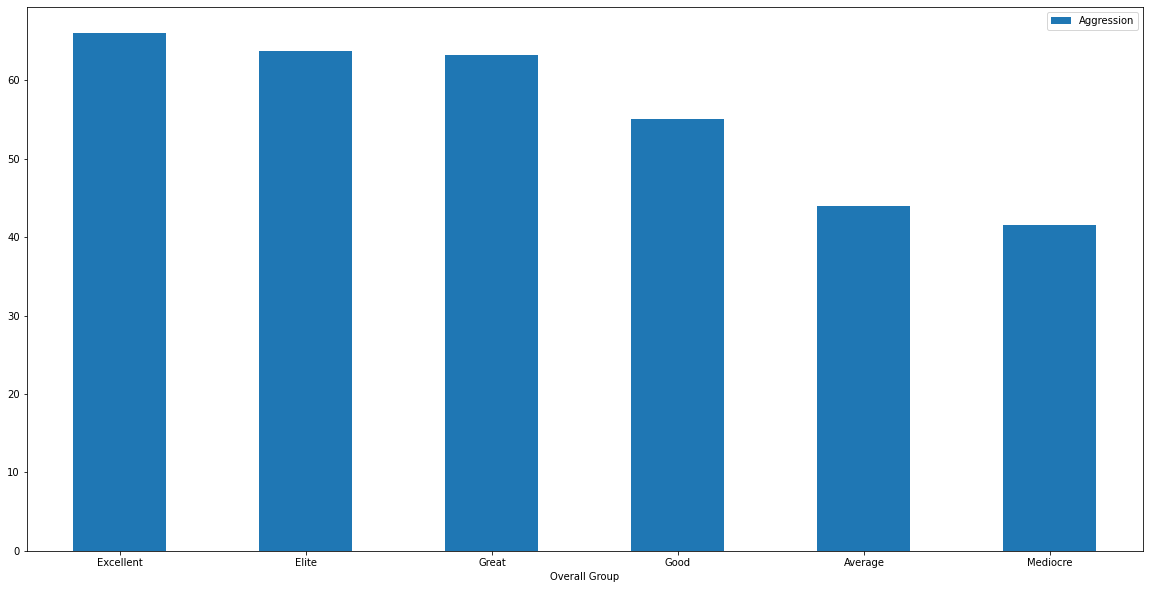

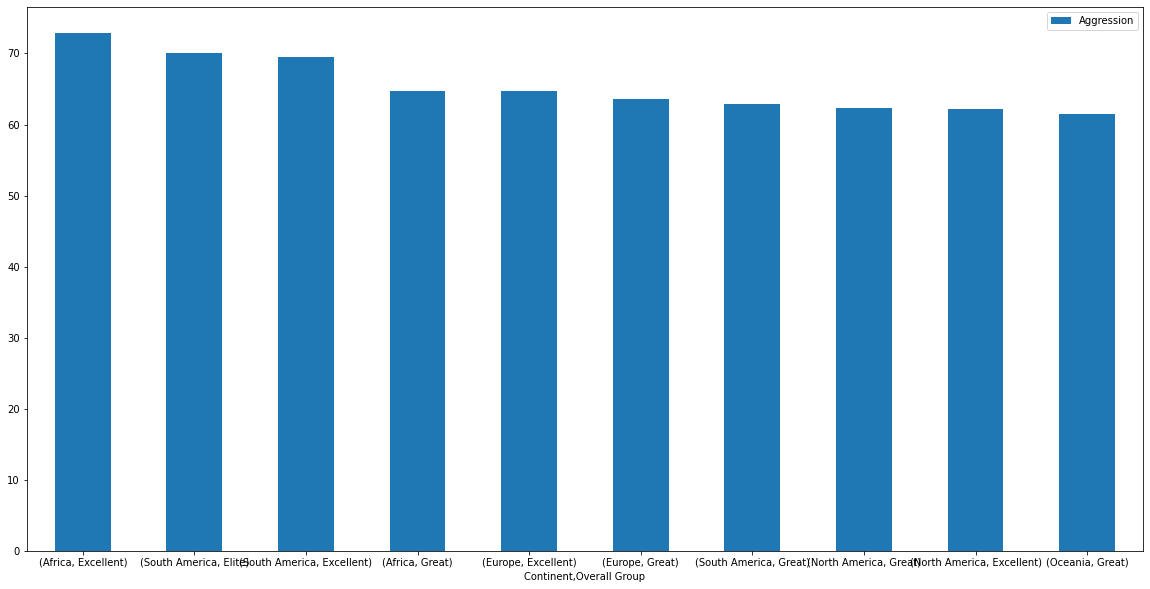

In [35]:
# NEW!!  

# Get the average Aggression based on Overall Group and Continent.
#
my_fifa.group_by_columns_and_agg(['Continent'], 'Aggression', 'mean')
my_fifa.group_by_columns_and_agg(['Overall Group'], 'Aggression', 'mean')
my_fifa.group_by_columns_and_agg(['Continent', 'Overall Group'], 'Aggression', 'mean')

# Observation:  The Excellent, Elite and Great players have a noticeably higher Aggression rating.

Conducting a mean on Dribbling for the group ['Continent']
----------------------------
               Dribbling
Continent               
Africa         62.086667
South America  57.969192
Europe         54.824649
North America  53.598501
Asia           51.496012
Oceania        51.372340
----------------------------

Conducting a mean on Dribbling for the group ['Overall Group']
----------------------------
               Dribbling
Overall Group           
Elite          74.285714
Excellent      69.284658
Great          62.647452
Good           54.193200
Average        44.027353
Mediocre       38.303371
----------------------------

Conducting a mean on Dribbling for the group ['Continent', 'Overall Group']
----------------------------
                             Dribbling
Continent     Overall Group           
South America Elite          83.250000
Asia          Excellent      82.142857
Africa        Excellent      74.700000
North America Excellent      73.875000
South America Excelle

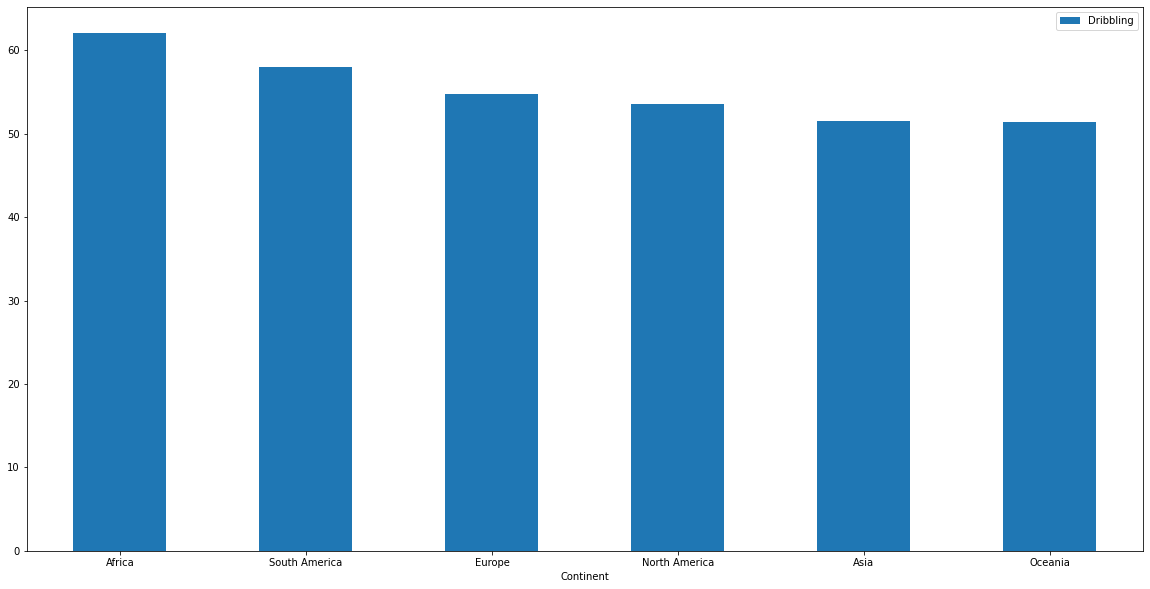

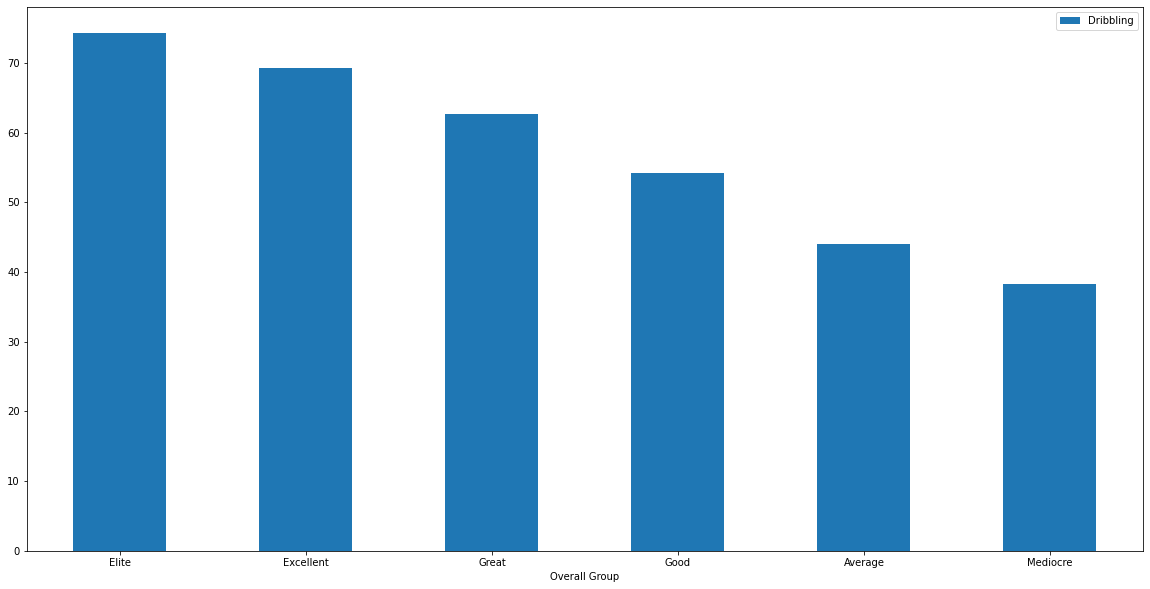

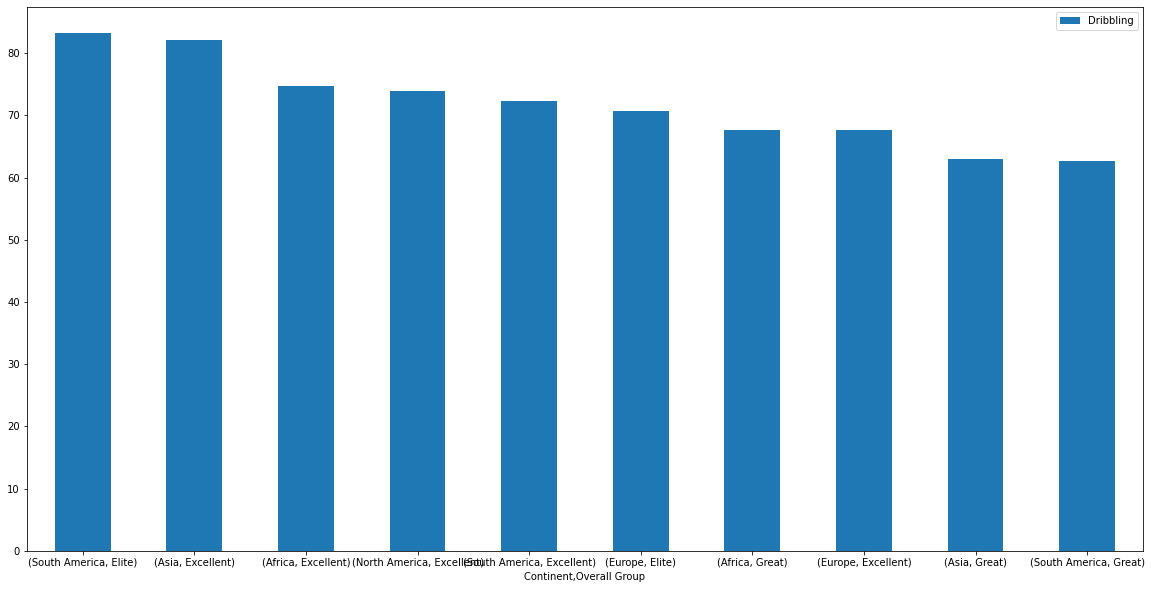

In [36]:
# NEW!!  

# Get the average Dribbling based on Overall Group and Continent.
#
my_fifa.group_by_columns_and_agg(['Continent'], 'Dribbling', 'mean')
my_fifa.group_by_columns_and_agg(['Overall Group'], 'Dribbling', 'mean')
my_fifa.group_by_columns_and_agg(['Continent', 'Overall Group'], 'Dribbling', 'mean')

# Observation:  The Elite, Excellent and Great players have a noticeably higher Dribbling rating.

Conducting a mean on Finishing for the group ['Continent']
----------------------------
               Finishing
Continent               
Africa         50.904167
South America  48.094939
Europe         45.085354
North America  43.312634
Oceania        42.858156
Asia           42.184945
----------------------------

Conducting a mean on Finishing for the group ['Overall Group']
----------------------------
               Finishing
Overall Group           
Elite          69.714286
Excellent      58.861368
Great          52.283297
Good           44.296038
Average        35.506217
Mediocre       29.640449
----------------------------

Conducting a mean on Finishing for the group ['Continent', 'Overall Group']
----------------------------
                             Finishing
Continent     Overall Group           
South America Elite          79.250000
Asia          Excellent      68.714286
North America Excellent      66.625000
Europe        Elite          65.900000
South America Excelle

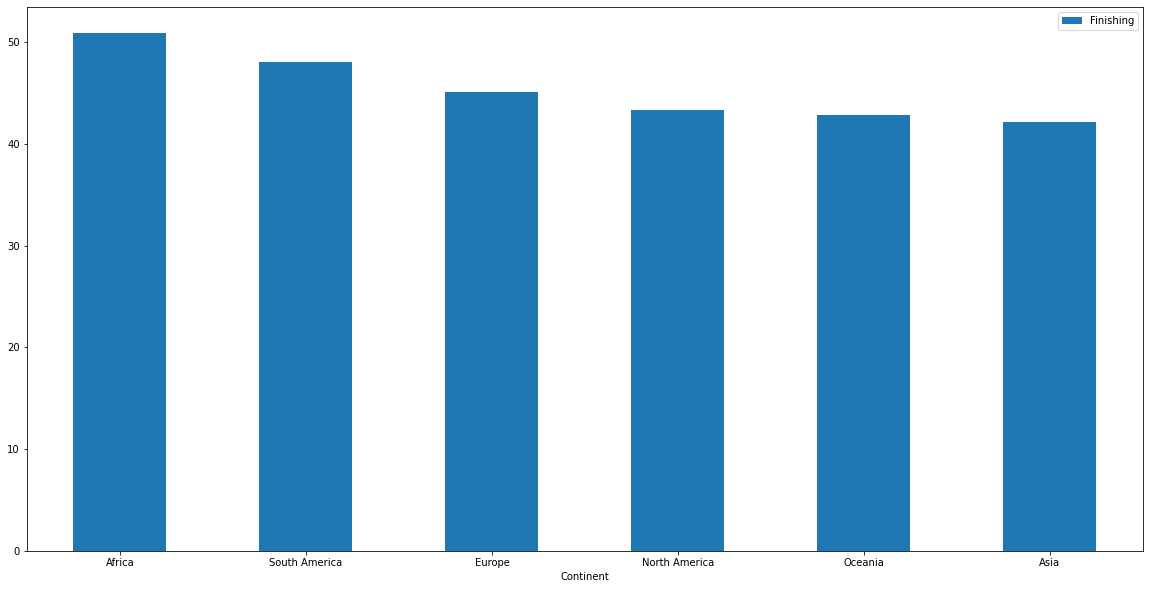

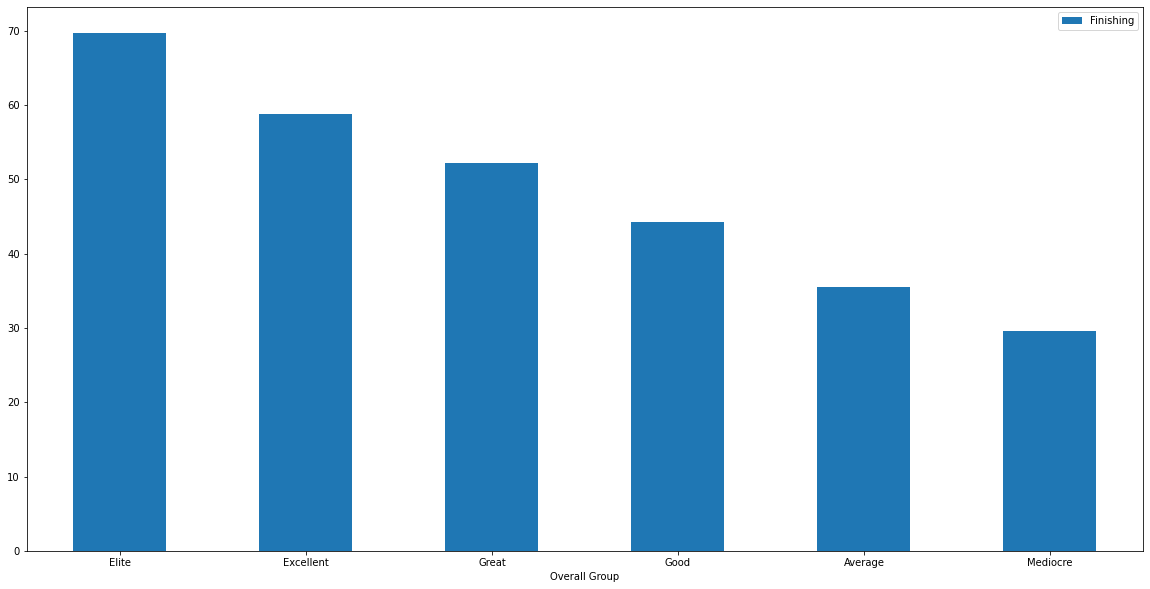

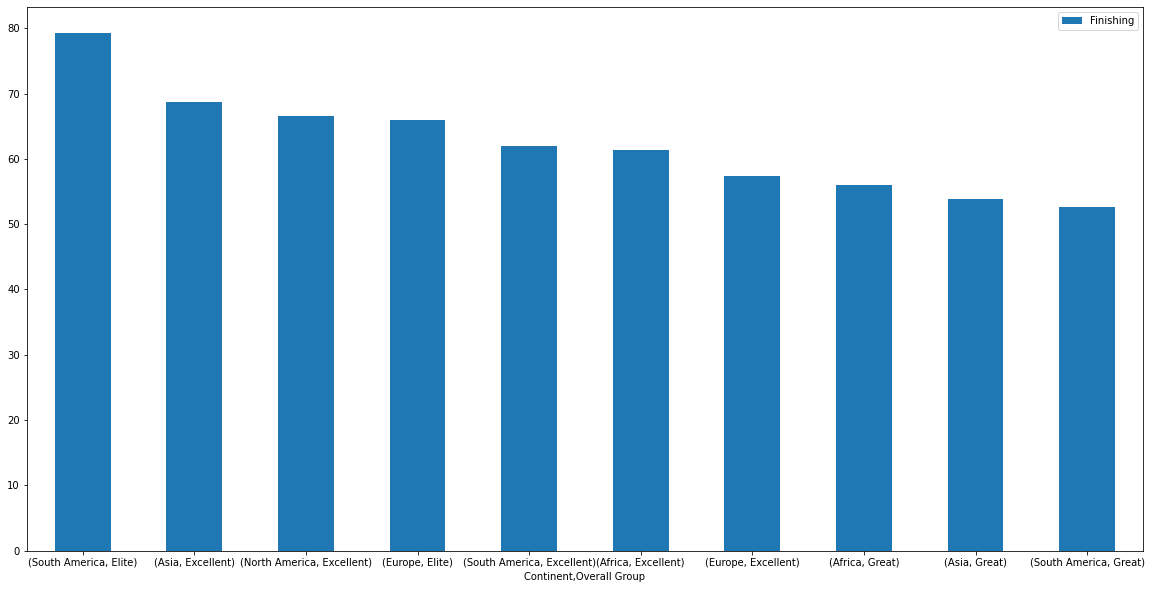

In [37]:
# NEW!!  

# Get the average Finishing based on Overall Group and Continent.
#
my_fifa.group_by_columns_and_agg(['Continent'], 'Finishing', 'mean')
my_fifa.group_by_columns_and_agg(['Overall Group'], 'Finishing', 'mean')
my_fifa.group_by_columns_and_agg(['Continent', 'Overall Group'], 'Finishing', 'mean')

# Observation:  The Elite, Excellent and Great players have a noticeably higher Finishing rating.

Conducting a mean on GKDiving for the group ['Continent']
----------------------------
                GKDiving
Continent               
North America  18.468951
Oceania        17.563830
Asia           17.111665
Europe         16.986169
South America  15.737818
Africa         13.197500
----------------------------

Conducting a mean on GKDiving for the group ['Overall Group']
----------------------------
                GKDiving
Overall Group           
Elite          22.285714
Excellent      19.073937
Average        18.755595
Mediocre       17.235955
Good           16.142976
Great          16.038757
----------------------------

Conducting a mean on GKDiving for the group ['Continent', 'Overall Group']
----------------------------
                              GKDiving
Continent     Overall Group           
Europe        Elite          26.400000
North America Average        21.863014
Oceania       Great          20.970588
Europe        Excellent      20.704188
North America Excellent 

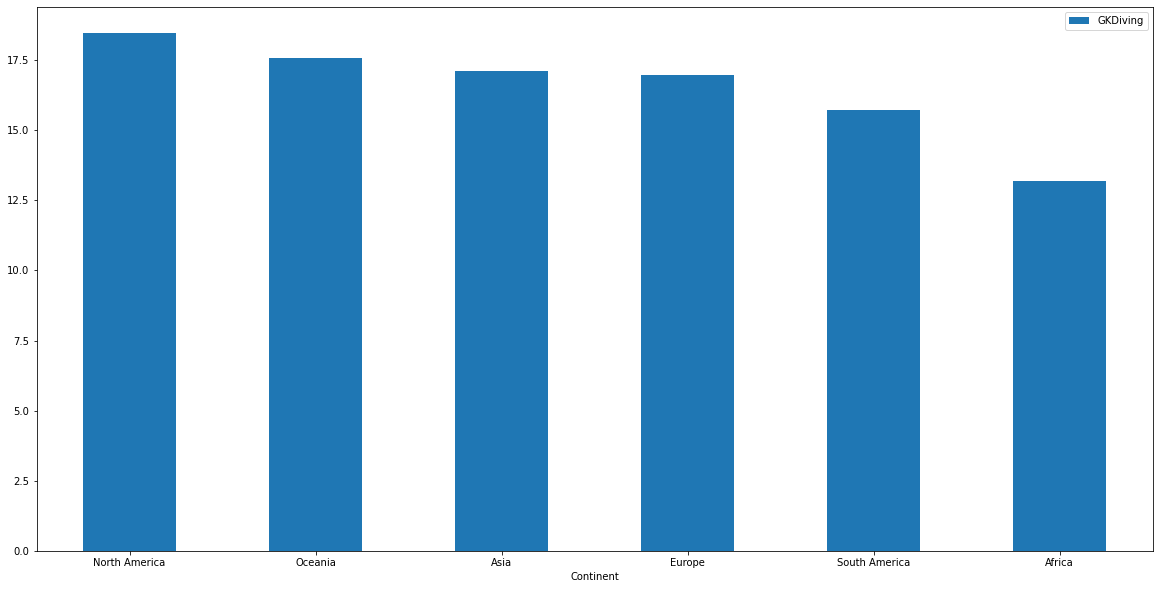

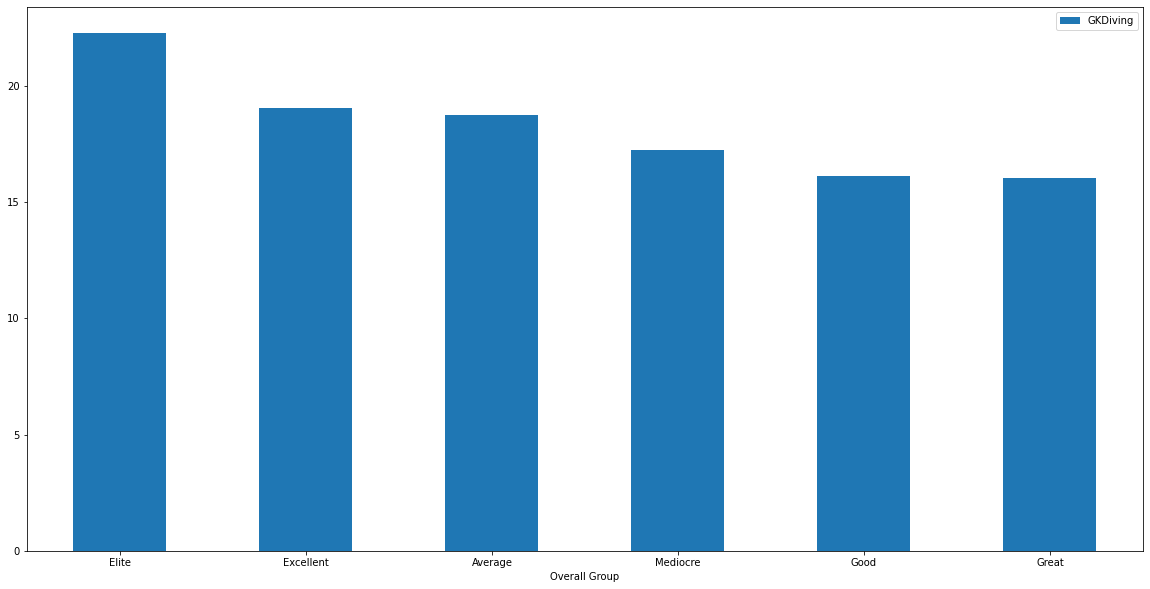

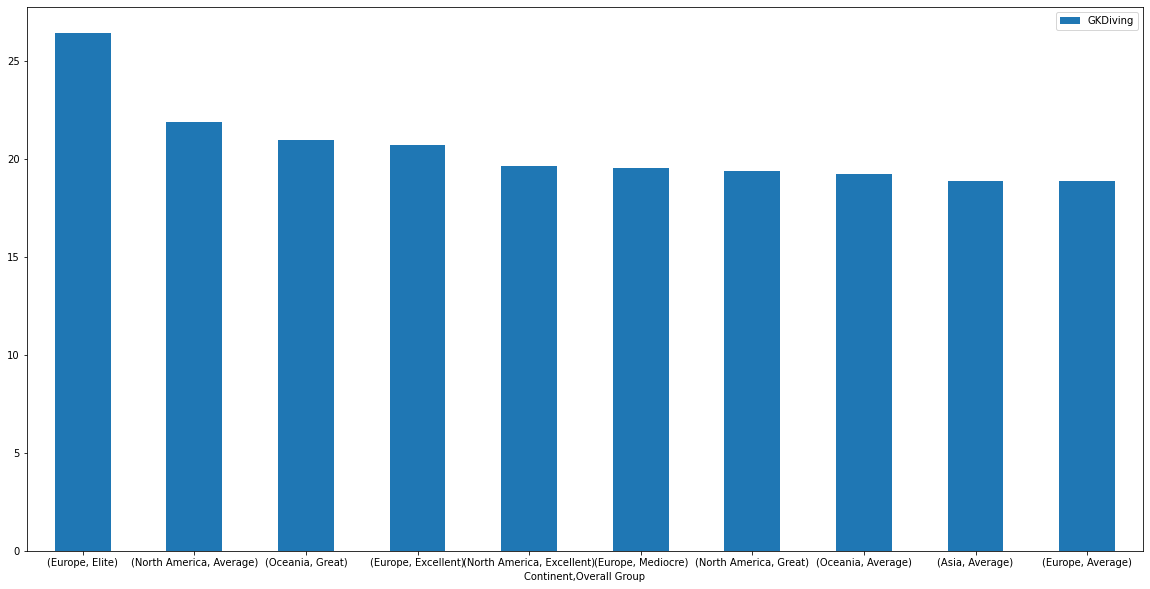

In [38]:
# NEW!!  

# Get the average GKDiving based on Overall Group and Continent.
#
my_fifa.group_by_columns_and_agg(['Continent'], 'GKDiving', 'mean')
my_fifa.group_by_columns_and_agg(['Overall Group'], 'GKDiving', 'mean')
my_fifa.group_by_columns_and_agg(['Continent', 'Overall Group'], 'GKDiving', 'mean')

# Observation:  Given the range of possible values in GKDiving and how close they are all
# together, this doesn't appear to be a significant attribute.

Conducting a mean on Weak Foot for the group ['Overall Group']
----------------------------
               Weak Foot
Overall Group           
Elite           3.785714
Excellent       3.280961
Great           3.076530
Good            2.923261
Average         2.735702
Mediocre        2.696629
----------------------------



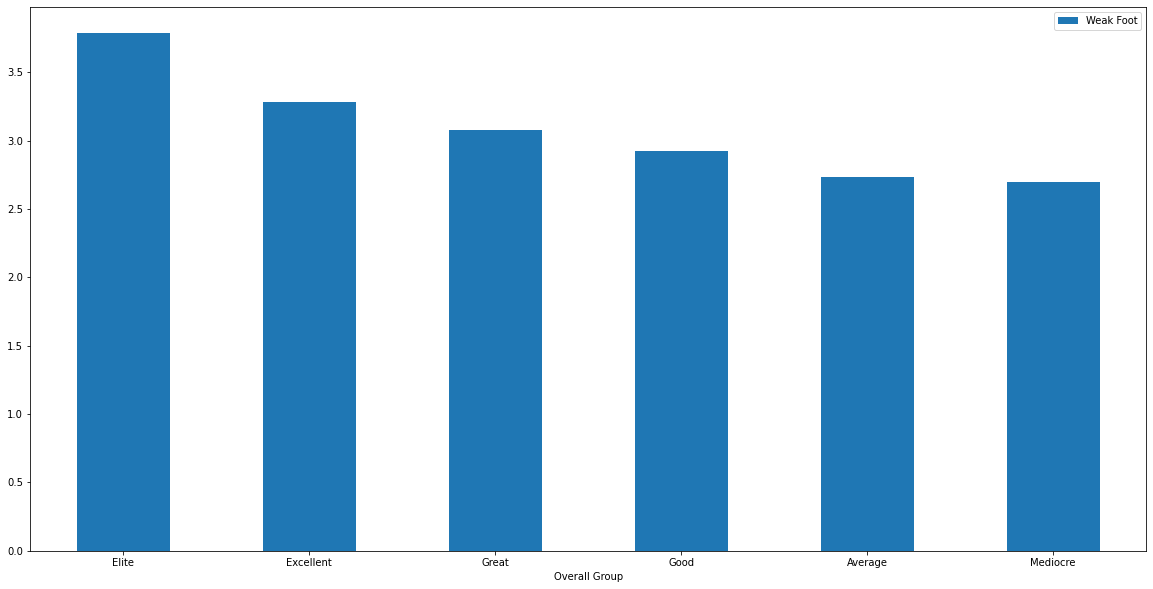

In [39]:
# Get the average GKDiving based on Overall Group and Continent.
#
my_fifa.group_by_columns_and_agg(['Overall Group'], 'Weak Foot', 'mean')

# maybe

Conducting a mean on Skill Moves for the group ['Overall Group']
----------------------------
               Skill Moves
Overall Group             
Elite             3.357143
Excellent         3.009242
Great             2.698800
Good              2.286576
Average           1.894494
Mediocre          1.831461
----------------------------



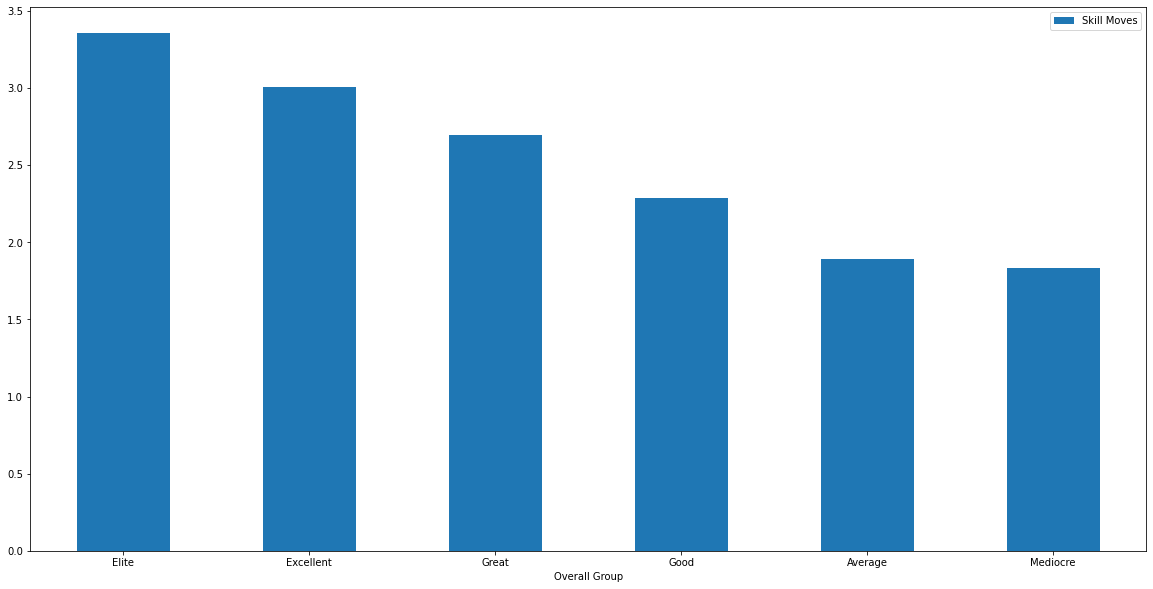

In [40]:
my_fifa.group_by_columns_and_agg(['Overall Group'], 'Skill Moves', 'mean')

# yes

Conducting a mean on Crossing for the group ['Overall Group']
----------------------------
                Crossing
Overall Group           
Elite          69.214286
Excellent      63.059150
Great          57.110171
Good           48.786940
Average        37.562345
Mediocre       31.752809
----------------------------



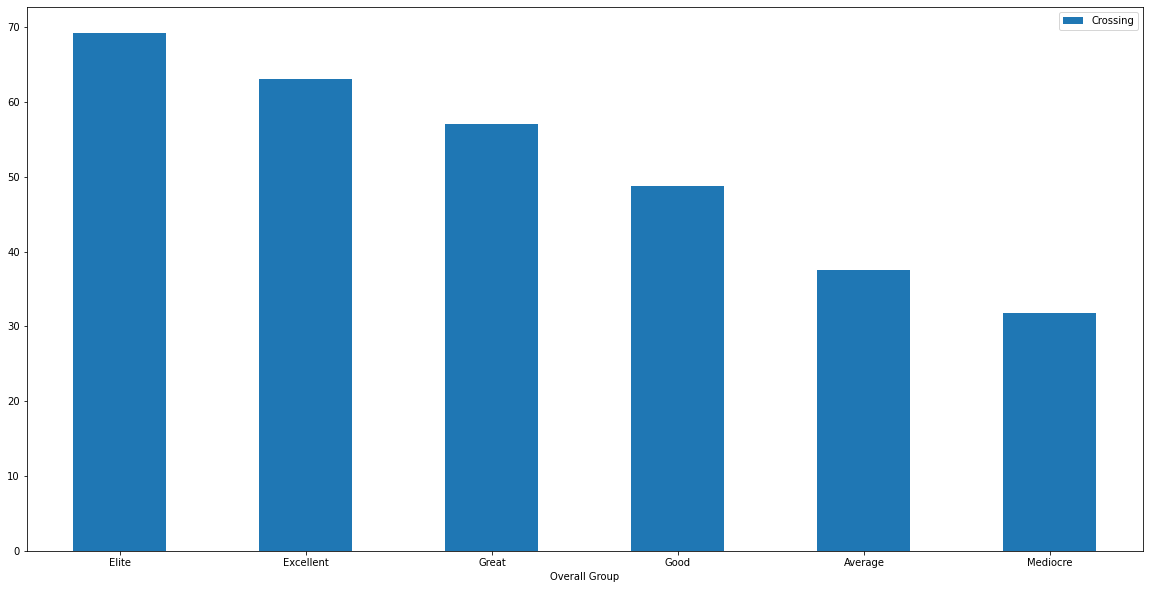

In [41]:
my_fifa.group_by_columns_and_agg(['Overall Group'], 'Crossing', 'mean')

# yes - < 30% difference between Elite and Mediocre;  16 out of 34 attributes were chosen

Conducting a mean on Finishing for the group ['Overall Group']
----------------------------
               Finishing
Overall Group           
Elite          69.714286
Excellent      58.861368
Great          52.283297
Good           44.296038
Average        35.506217
Mediocre       29.640449
----------------------------



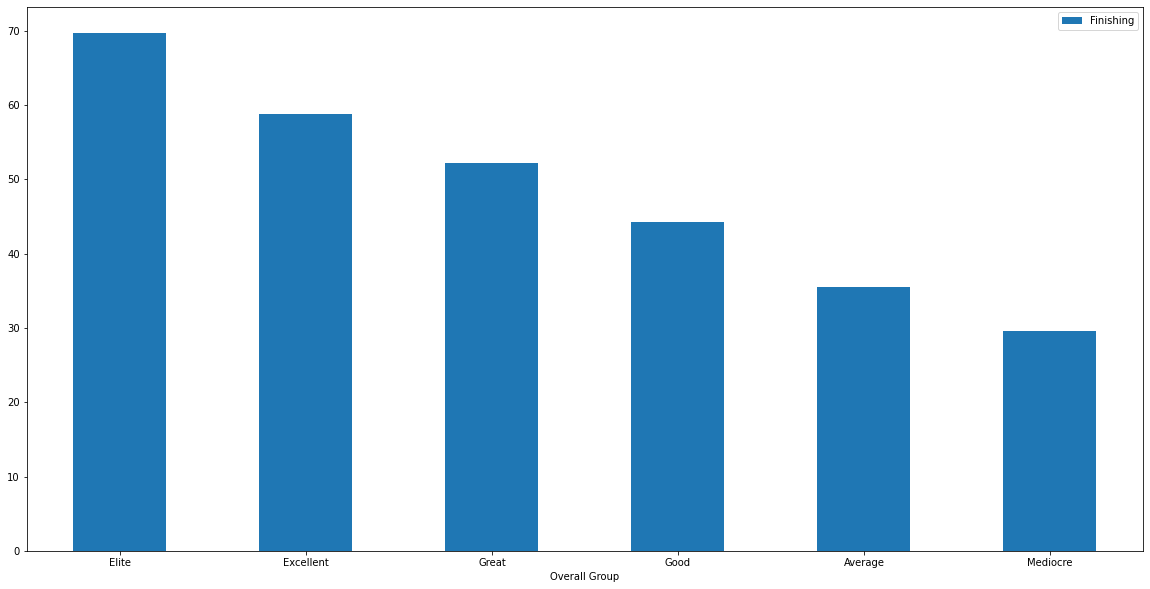

In [42]:
my_fifa.group_by_columns_and_agg(['Overall Group'], 'Finishing', 'mean')
# yes

Conducting a mean on HeadingAccuracy for the group ['Overall Group']
----------------------------
               HeadingAccuracy
Overall Group                 
Elite                62.928571
Excellent            61.162662
Great                58.604171
Good                 51.608922
Average              42.019183
Mediocre             36.179775
----------------------------



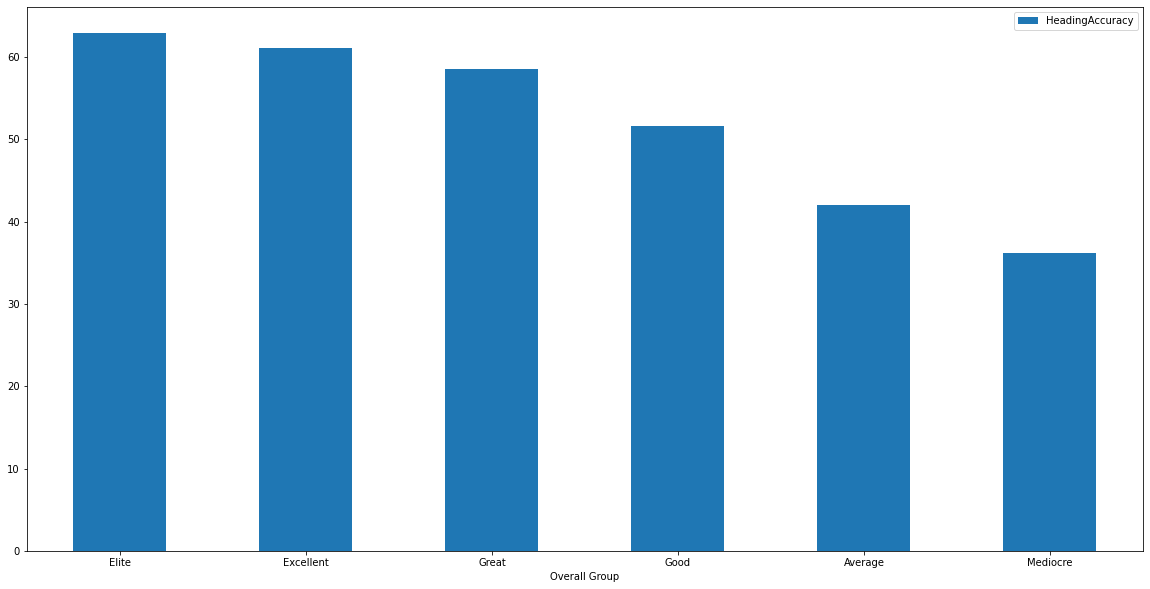

In [43]:
my_fifa.group_by_columns_and_agg(['Overall Group'], 'HeadingAccuracy', 'mean')
# no

Conducting a mean on ShortPassing for the group ['Overall Group']
----------------------------
               ShortPassing
Overall Group              
Elite             79.642857
Excellent         73.487985
Great             66.217785
Good              57.538733
Average           46.577975
Mediocre          42.337079
----------------------------



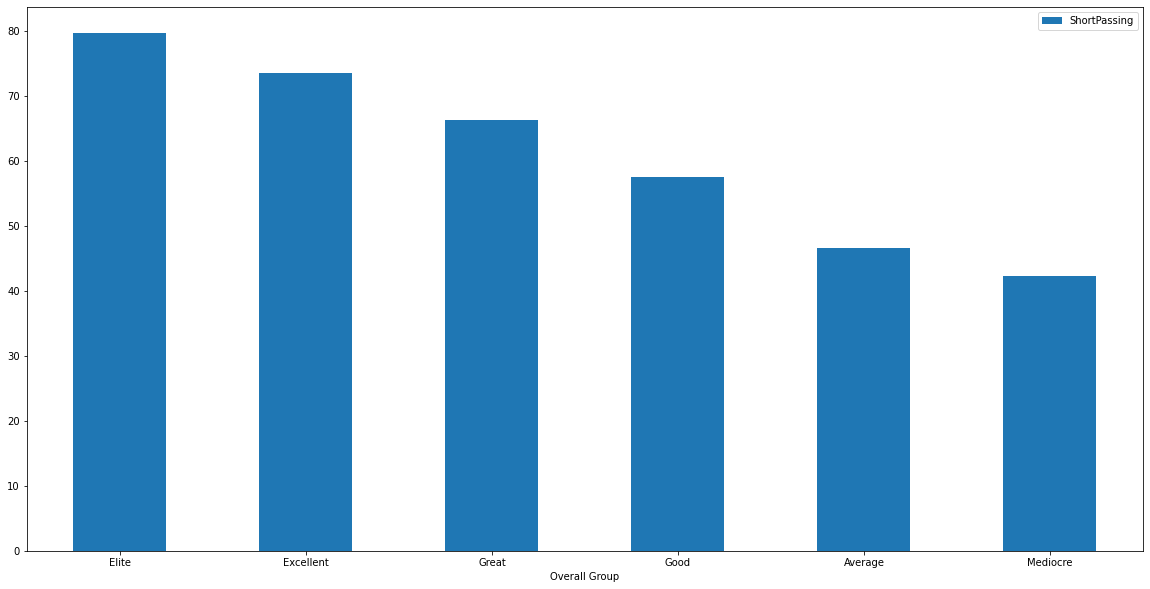

In [44]:
my_fifa.group_by_columns_and_agg(['Overall Group'], 'ShortPassing', 'mean')
# yes

Conducting a mean on Dribbling for the group ['Overall Group']
----------------------------
               Dribbling
Overall Group           
Elite          74.285714
Excellent      69.284658
Great          62.647452
Good           54.193200
Average        44.027353
Mediocre       38.303371
----------------------------



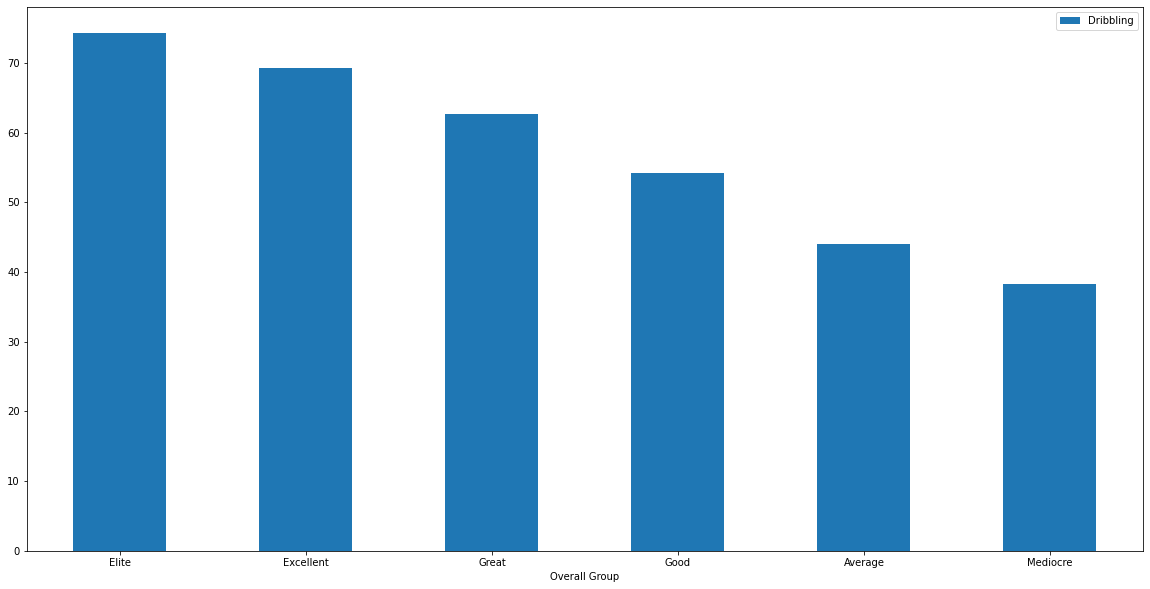

In [45]:
my_fifa.group_by_columns_and_agg(['Overall Group'], 'Dribbling', 'mean')
# yes

Conducting a mean on Curve for the group ['Overall Group']
----------------------------
                   Curve
Overall Group           
Elite          71.642857
Excellent      62.674677
Great          55.488688
Good           45.485079
Average        35.307282
Mediocre       31.415730
----------------------------



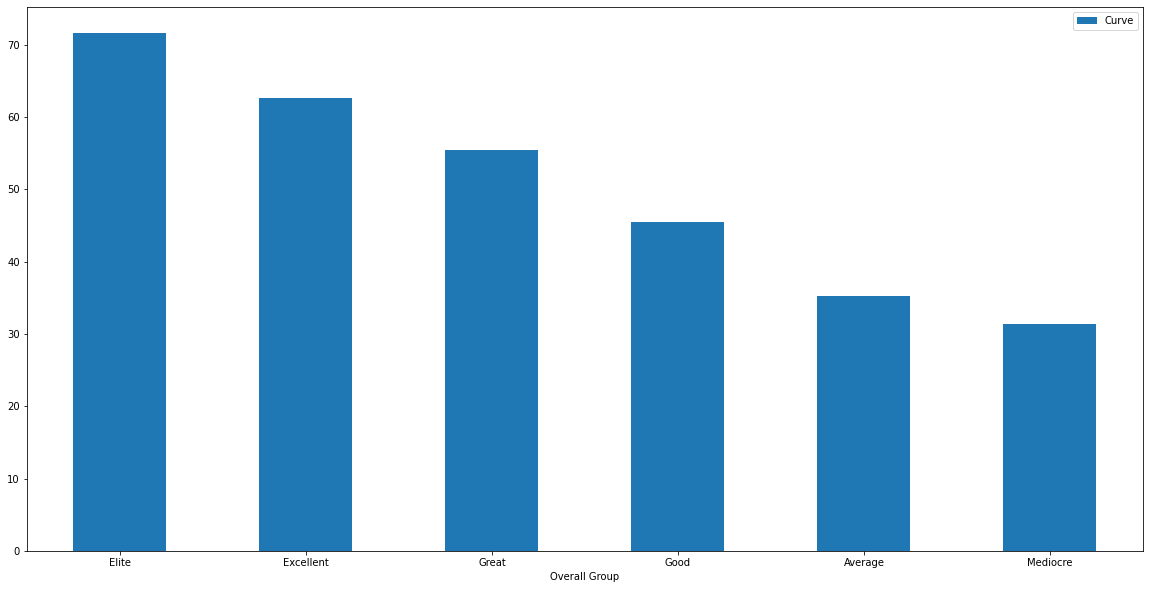

In [46]:
my_fifa.group_by_columns_and_agg(['Overall Group'], 'Curve', 'mean')
# yes

Conducting a mean on FKAccuracy for the group ['Overall Group']
----------------------------
               FKAccuracy
Overall Group            
Elite           70.285714
Excellent       56.646950
Great           50.387960
Good            41.335136
Average         32.132504
Mediocre        29.516854
----------------------------



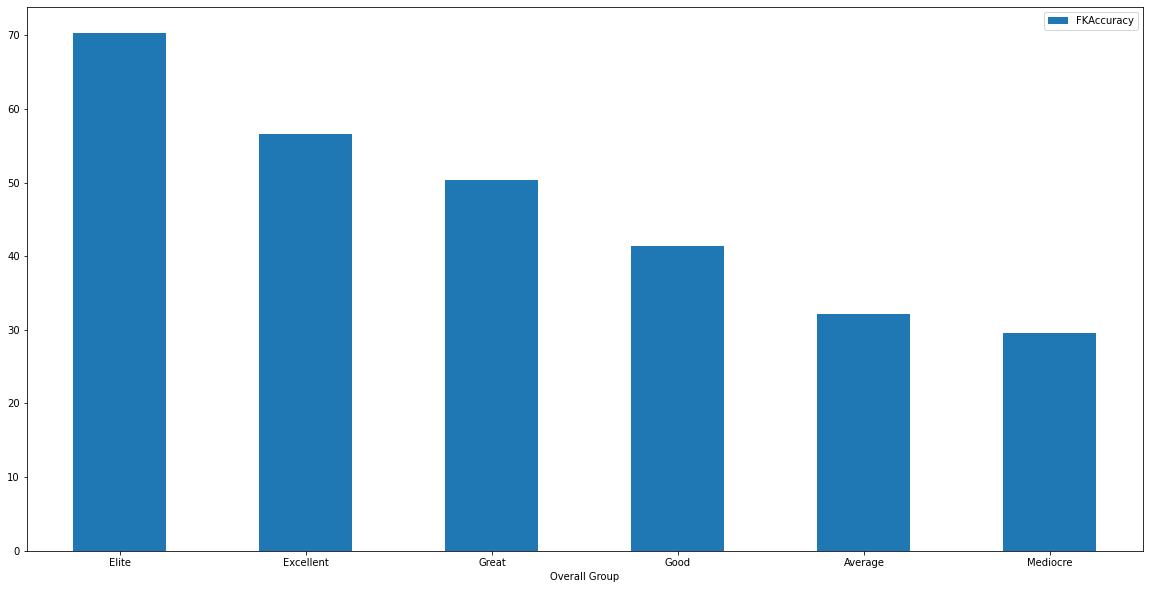

In [47]:
my_fifa.group_by_columns_and_agg(['Overall Group'], 'FKAccuracy', 'mean')
# yes

Conducting a mean on LongPassing for the group ['Overall Group']
----------------------------
               LongPassing
Overall Group             
Elite            74.071429
Excellent        67.700555
Great            60.438914
Good             51.385255
Average          40.778686
Mediocre         37.730337
----------------------------



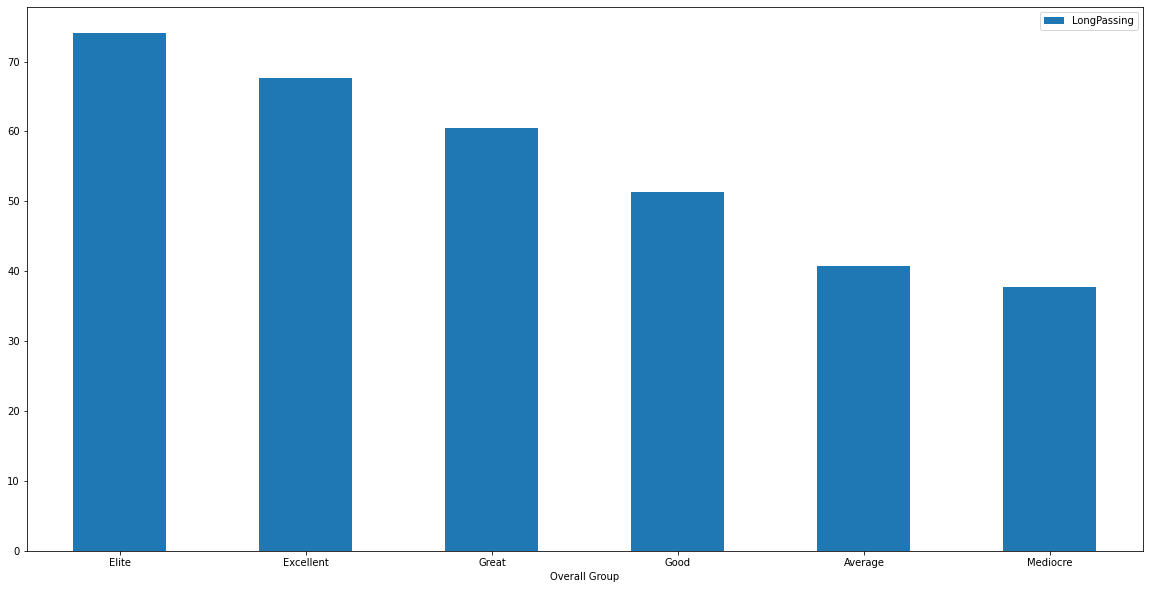

In [48]:
my_fifa.group_by_columns_and_agg(['Overall Group'], 'LongPassing', 'mean')
# yes

Conducting a mean on BallControl for the group ['Overall Group']
----------------------------
               BallControl
Overall Group             
Elite            81.714286
Excellent        73.059150
Great            66.178831
Good             57.292711
Average          45.618117
Mediocre         39.056180
----------------------------



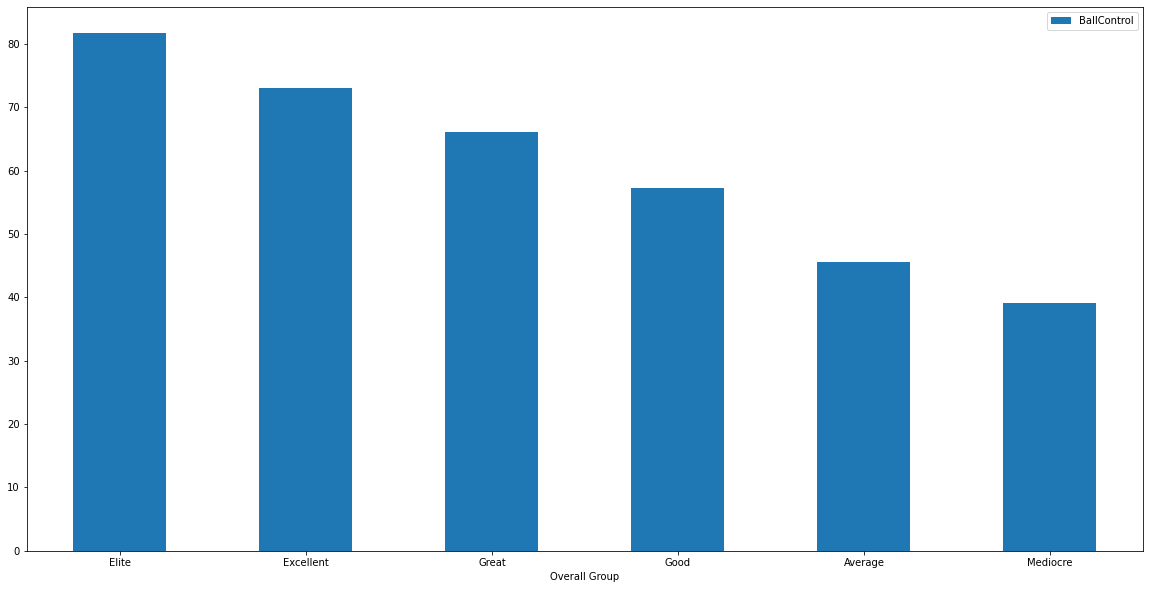

In [49]:
my_fifa.group_by_columns_and_agg(['Overall Group'], 'BallControl', 'mean')
# yes

Conducting a mean on Acceleration for the group ['Overall Group']
----------------------------
               Acceleration
Overall Group              
Elite             76.214286
Excellent         70.251386
Great             67.025772
Good              64.691927
Average           59.142806
Mediocre          55.382022
----------------------------



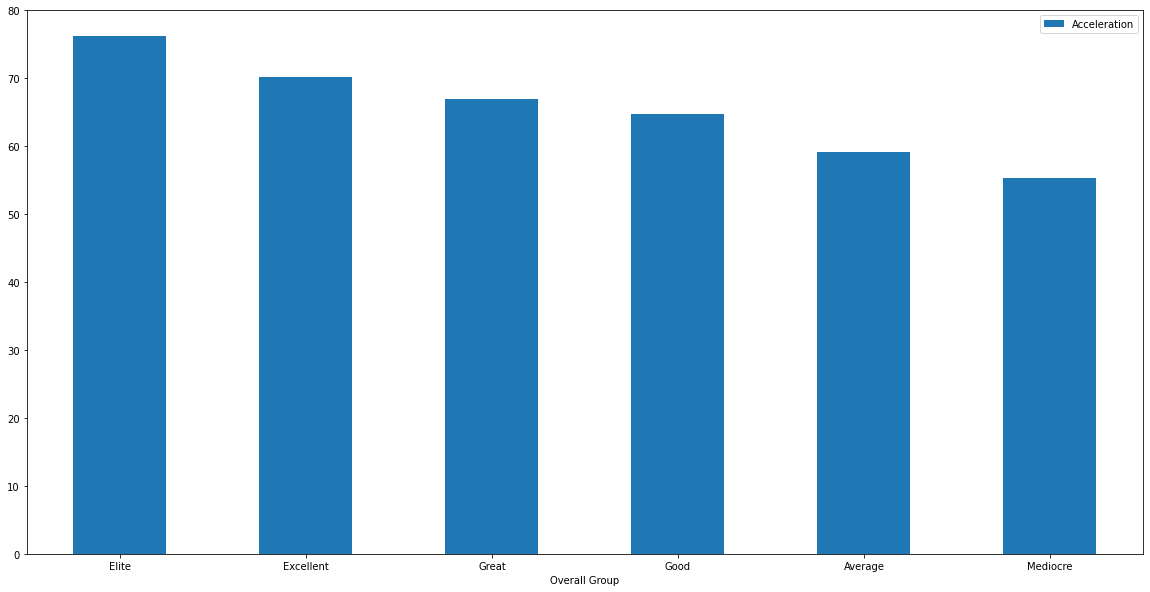

In [50]:
my_fifa.group_by_columns_and_agg(['Overall Group'], 'Acceleration', 'mean')
#no

Conducting a mean on SprintSpeed for the group ['Overall Group']
----------------------------
               SprintSpeed
Overall Group             
Elite            74.500000
Excellent        70.622921
Great            67.192209
Good             64.872101
Average          58.920426
Mediocre         54.528090
----------------------------



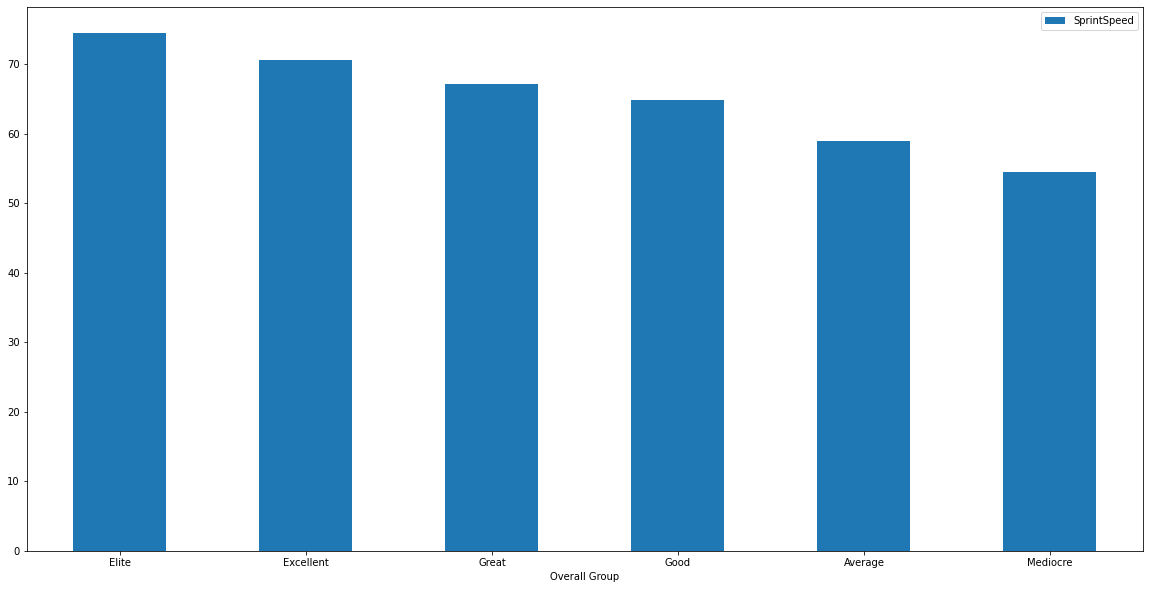

In [51]:
my_fifa.group_by_columns_and_agg(['Overall Group'], 'SprintSpeed', 'mean')
#no

Conducting a mean on Agility for the group ['Overall Group']
----------------------------
                 Agility
Overall Group           
Elite          80.428571
Excellent      70.441774
Great          67.091678
Good           63.375186
Average        56.386501
Mediocre       52.797753
----------------------------



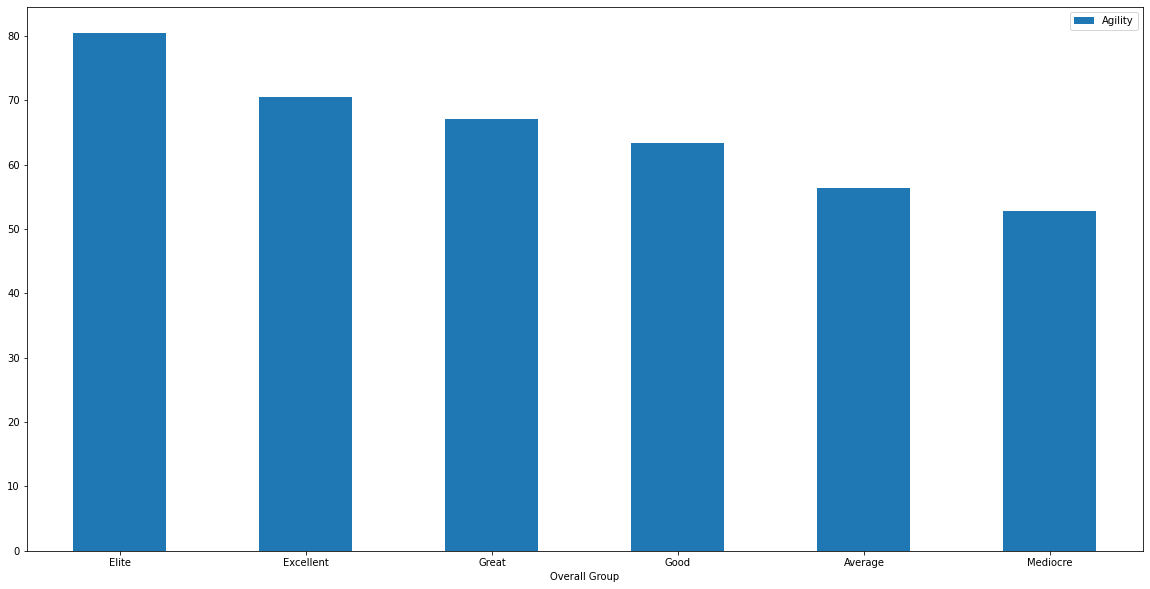

In [52]:
my_fifa.group_by_columns_and_agg(['Overall Group'], 'Agility', 'mean')
# no

Conducting a mean on Reactions for the group ['Overall Group']
----------------------------
               Reactions
Overall Group           
Elite          90.214286
Excellent      80.133087
Great          69.654338
Good           60.079582
Average        50.632327
Mediocre       44.853933
----------------------------



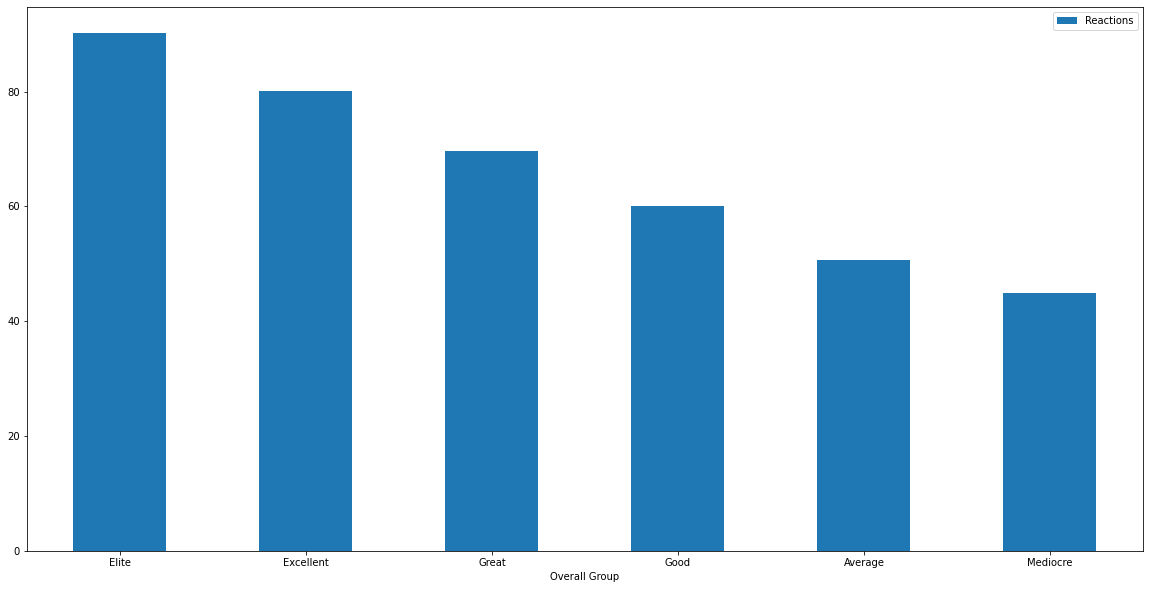

In [53]:
my_fifa.group_by_columns_and_agg(['Overall Group'], 'Reactions', 'mean')
# yes

Conducting a mean on Balance for the group ['Overall Group']
----------------------------
                 Balance
Overall Group           
Elite          74.857143
Excellent      67.382625
Great          65.286642
Good           63.792695
Average        61.602487
Mediocre       59.752809
----------------------------



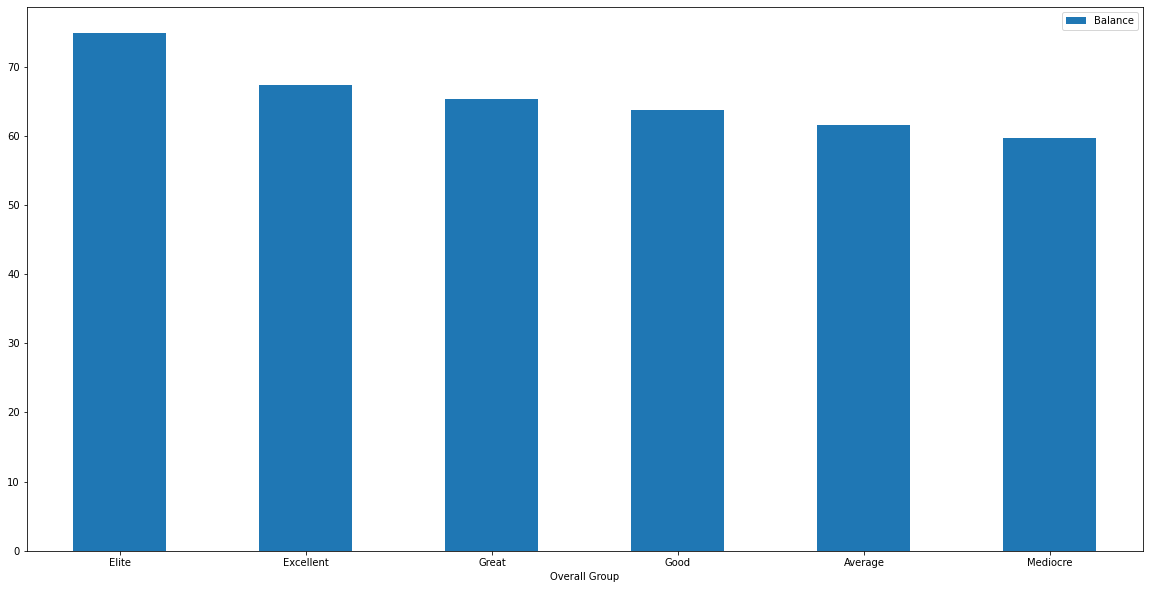

In [54]:
my_fifa.group_by_columns_and_agg(['Overall Group'], 'Balance', 'mean')
#no

Conducting a mean on ShotPower for the group ['Overall Group']
----------------------------
               ShotPower
Overall Group           
Elite          74.571429
Excellent      69.343808
Great          63.757623
Good           53.935323
Average        43.438366
Mediocre       39.157303
----------------------------



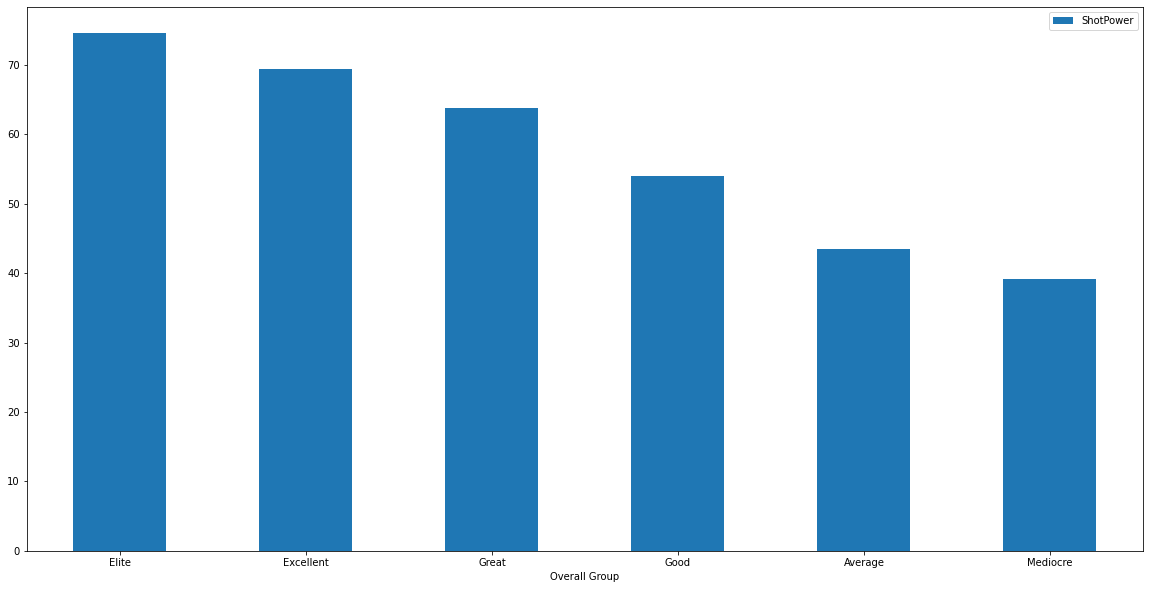

In [55]:
my_fifa.group_by_columns_and_agg(['Overall Group'], 'ShotPower', 'mean')
#yes

Conducting a mean on Jumping for the group ['Overall Group']
----------------------------
                 Jumping
Overall Group           
Elite          70.357143
Excellent      69.992606
Great          68.052331
Good           64.959135
Average        59.459680
Mediocre       57.382022
----------------------------



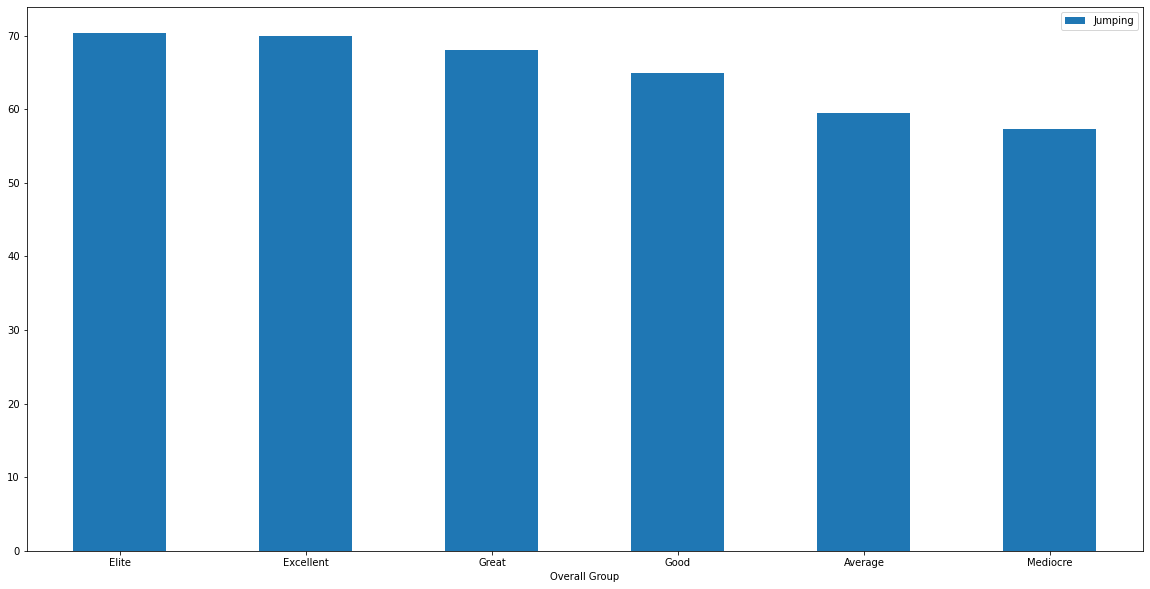

In [56]:
my_fifa.group_by_columns_and_agg(['Overall Group'], 'Jumping', 'mean')
#no

Conducting a mean on Stamina for the group ['Overall Group']
----------------------------
                 Stamina
Overall Group           
Elite          75.571429
Excellent      72.059150
Great          68.624631
Good           63.271810
Average        52.072824
Mediocre       45.842697
----------------------------



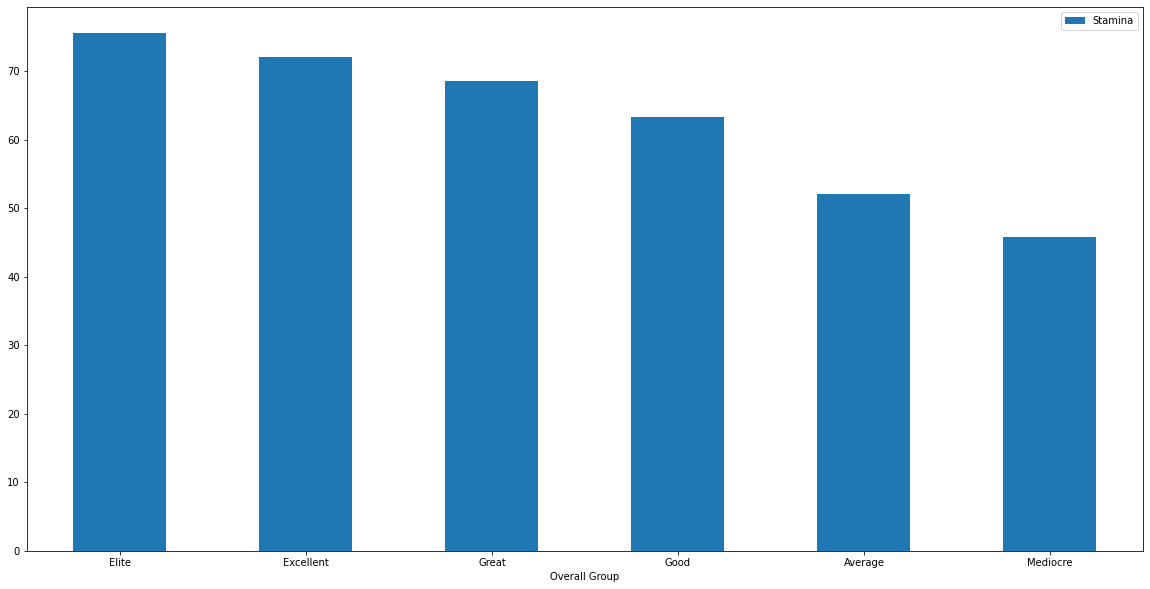

In [57]:
my_fifa.group_by_columns_and_agg(['Overall Group'], 'Stamina', 'mean')
#no

Conducting a mean on Strength for the group ['Overall Group']
----------------------------
                Strength
Overall Group           
Excellent      71.219963
Elite          70.785714
Great          69.397206
Good           65.474784
Average        56.700533
Mediocre       50.000000
----------------------------



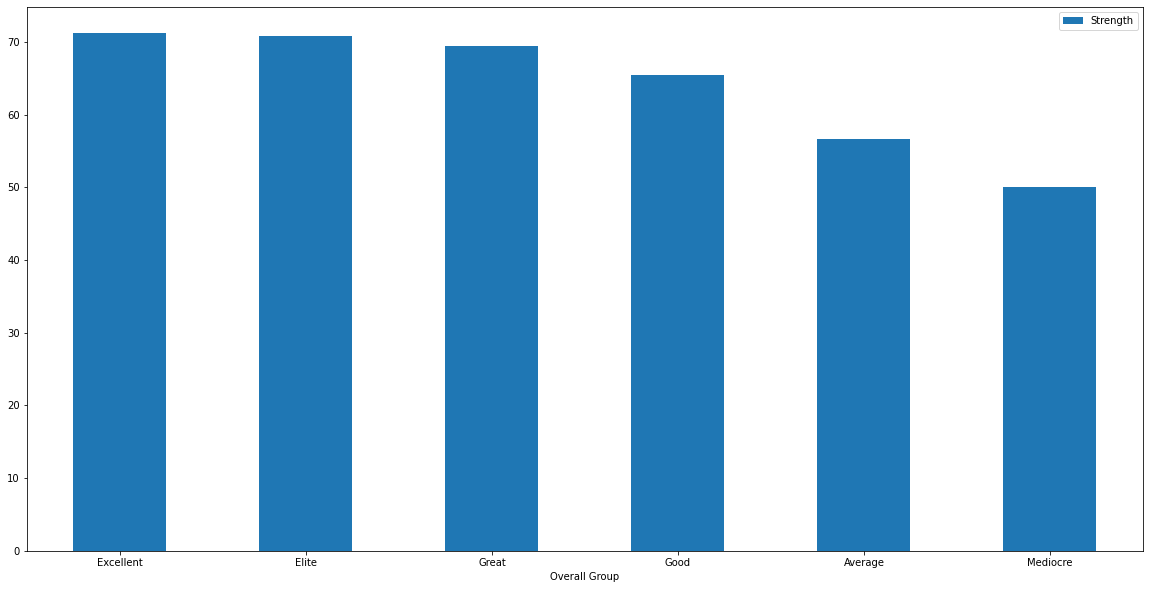

In [58]:
my_fifa.group_by_columns_and_agg(['Overall Group'], 'Strength', 'mean')
#no

Conducting a mean on LongShots for the group ['Overall Group']
----------------------------
               LongShots
Overall Group           
Elite          70.285714
Excellent      62.134935
Great          55.796774
Good           45.573984
Average        34.259680
Mediocre       28.426966
----------------------------



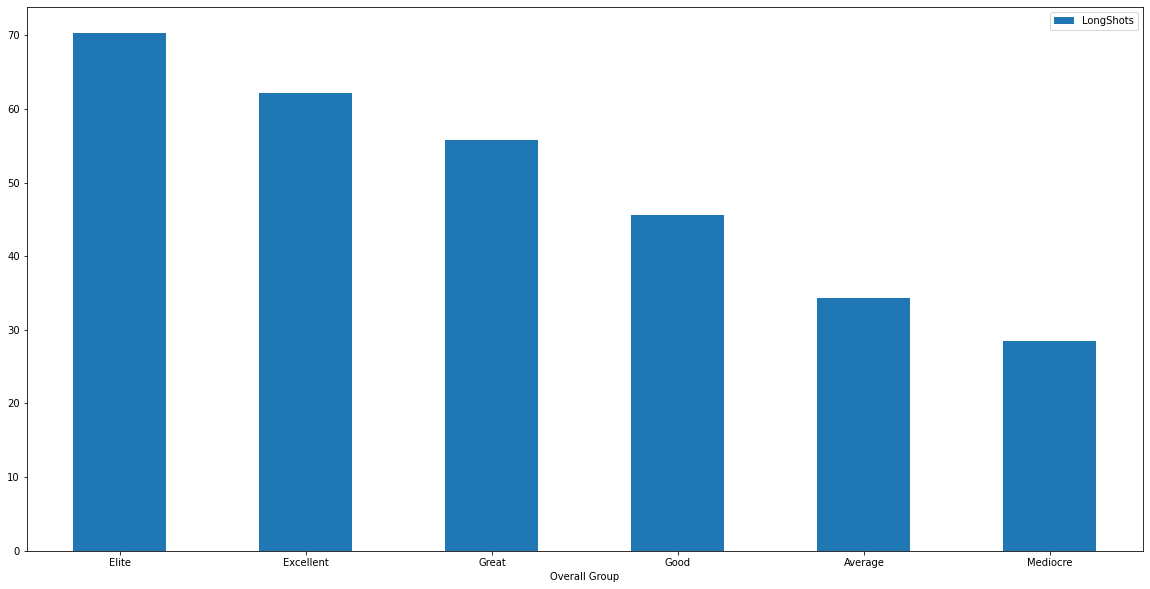

In [59]:
my_fifa.group_by_columns_and_agg(['Overall Group'], 'LongShots', 'mean')
#yes

Conducting a mean on Aggression for the group ['Overall Group']
----------------------------
               Aggression
Overall Group            
Excellent       66.024030
Elite           63.714286
Great           63.235688
Good            55.004367
Average         43.983659
Mediocre        41.528090
----------------------------



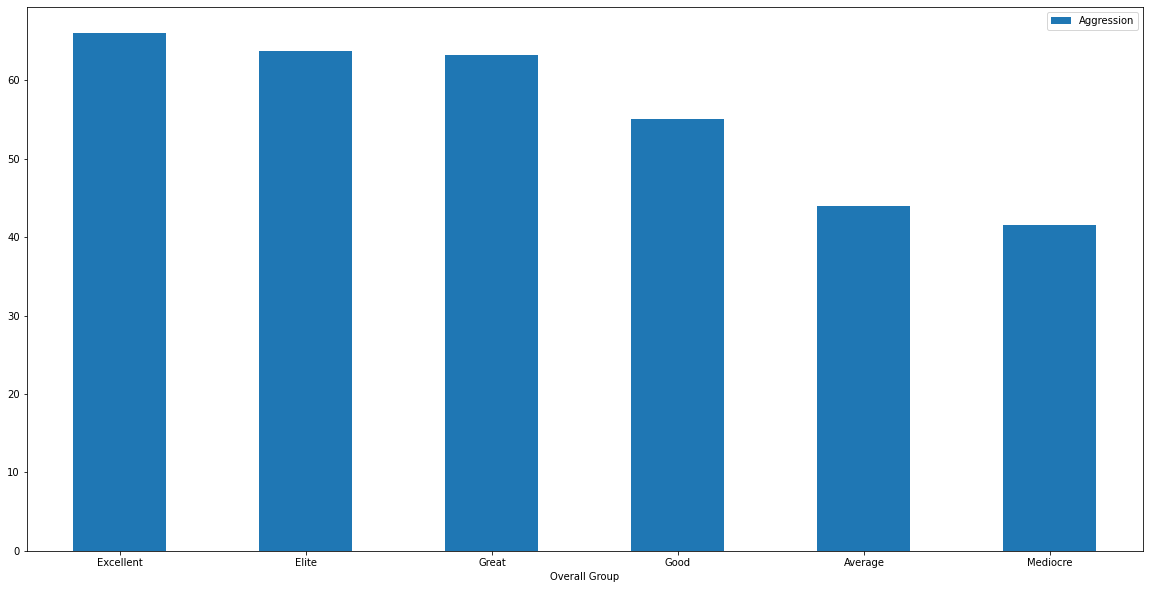

In [60]:
my_fifa.group_by_columns_and_agg(['Overall Group'], 'Aggression', 'mean')
#no

Conducting a mean on Interceptions for the group ['Overall Group']
----------------------------
               Interceptions
Overall Group               
Excellent          58.223660
Great              53.596892
Elite              50.785714
Good               46.049496
Average            34.627709
Mediocre           33.887640
----------------------------



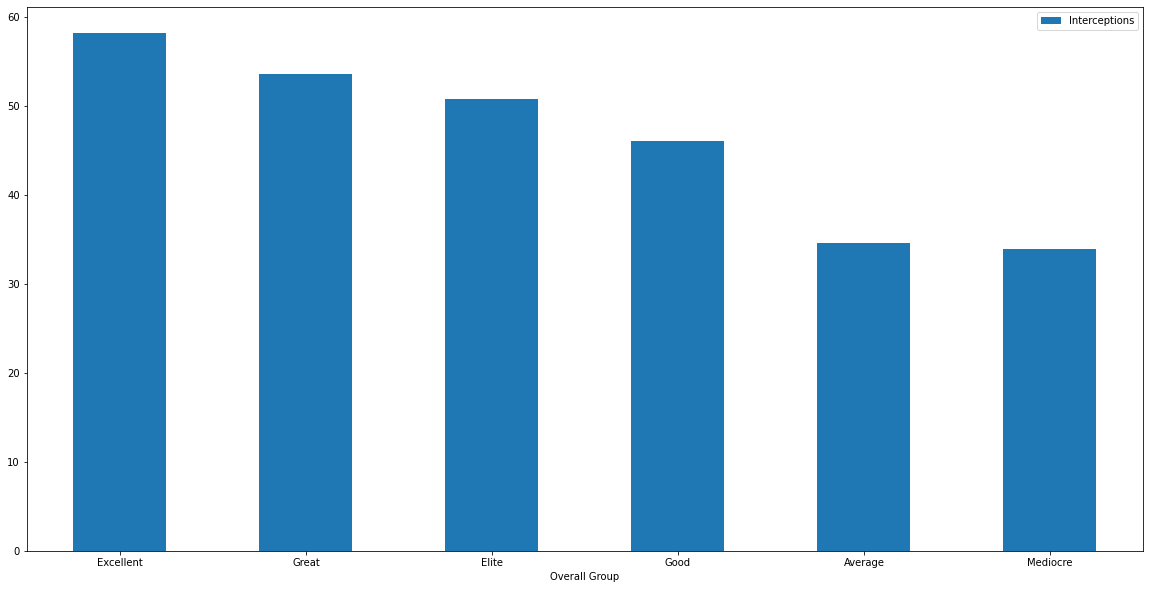

In [62]:
my_fifa.group_by_columns_and_agg(['Overall Group'], 'Interceptions', 'mean')
#no

Conducting a mean on Positioning for the group ['Overall Group']
----------------------------
               Positioning
Overall Group             
Elite            72.357143
Excellent        63.249538
Great            57.257919
Good             48.700218
Average          38.926110
Mediocre         33.662921
----------------------------



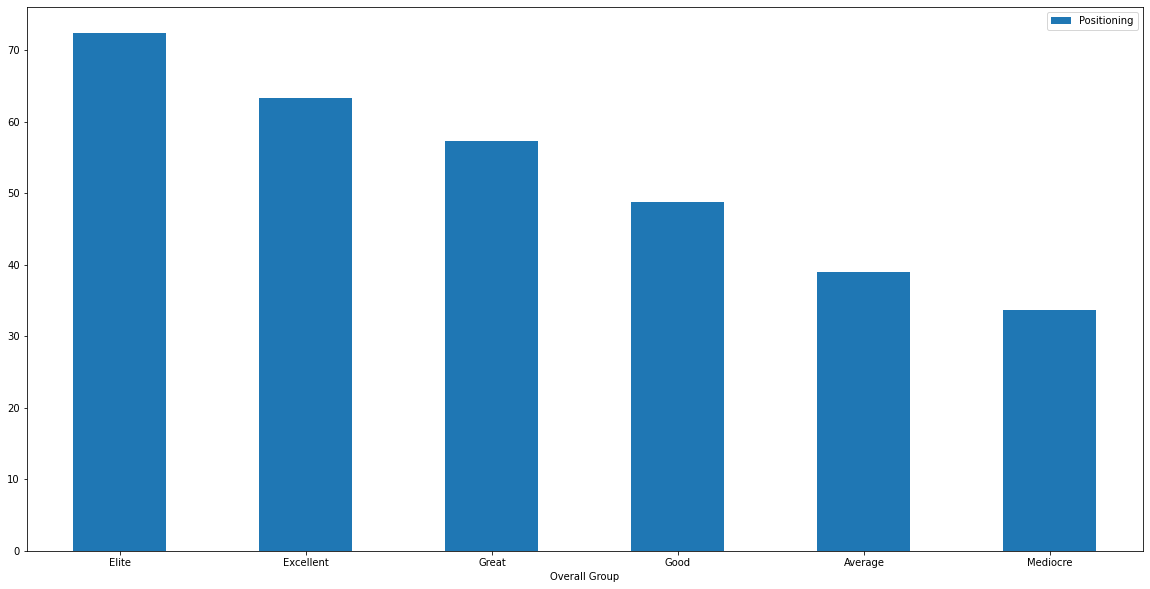

In [63]:
my_fifa.group_by_columns_and_agg(['Overall Group'], 'Positioning', 'mean')
#yes

Conducting a mean on Vision for the group ['Overall Group']
----------------------------
                  Vision
Overall Group           
Elite          80.714286
Excellent      70.624769
Great          60.812709
Good           51.554435
Average        43.298401
Mediocre       40.157303
----------------------------



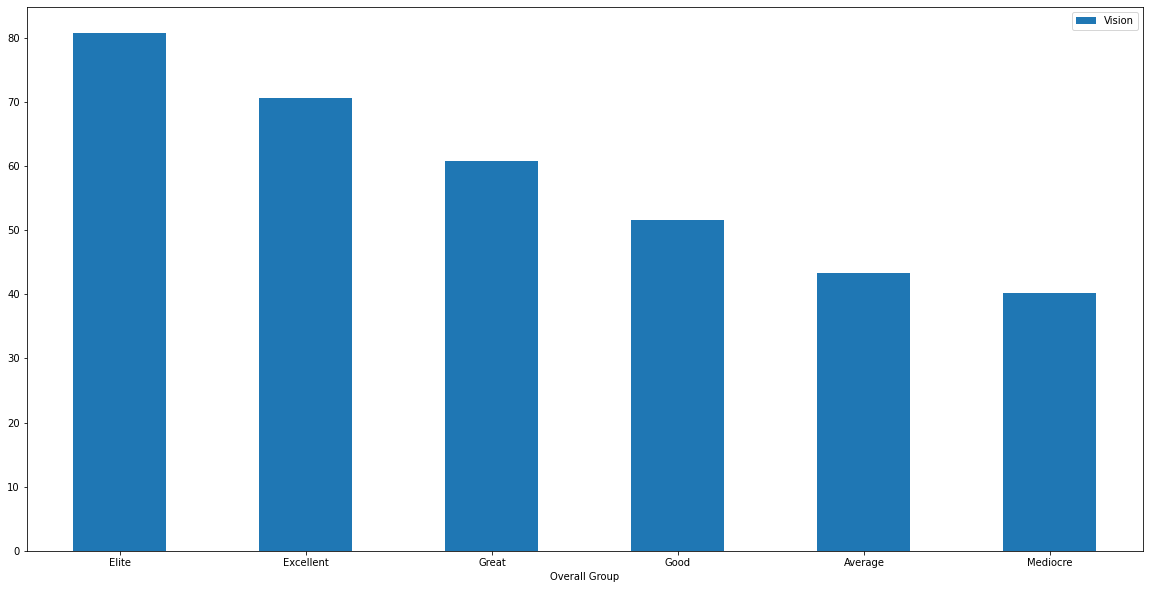

In [64]:
my_fifa.group_by_columns_and_agg(['Overall Group'], 'Vision', 'mean')
#yes

Conducting a mean on Penalties for the group ['Overall Group']
----------------------------
               Penalties
Overall Group           
Elite          70.357143
Excellent      59.412200
Great          54.444029
Good           47.200790
Average        40.719005
Mediocre       35.662921
----------------------------



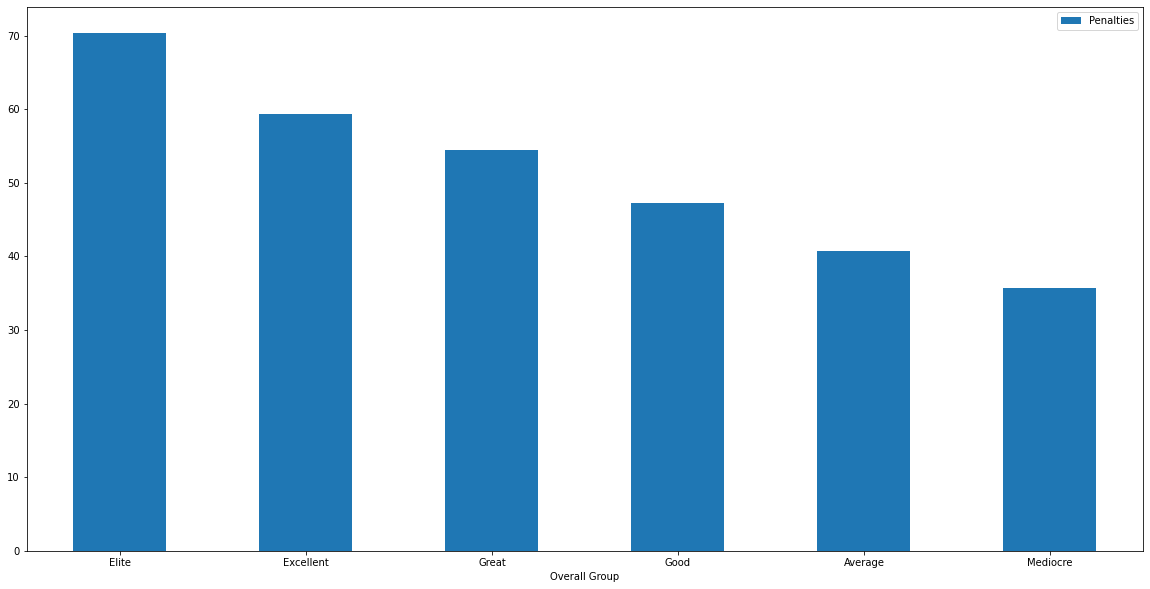

In [65]:
my_fifa.group_by_columns_and_agg(['Overall Group'], 'Penalties', 'mean')
#yes

Conducting a mean on Composure for the group ['Overall Group']
----------------------------
               Composure
Overall Group           
Elite          85.642857
Excellent      76.685767
Great          67.289003
Good           56.937403
Average        45.862167
Mediocre       40.550562
----------------------------



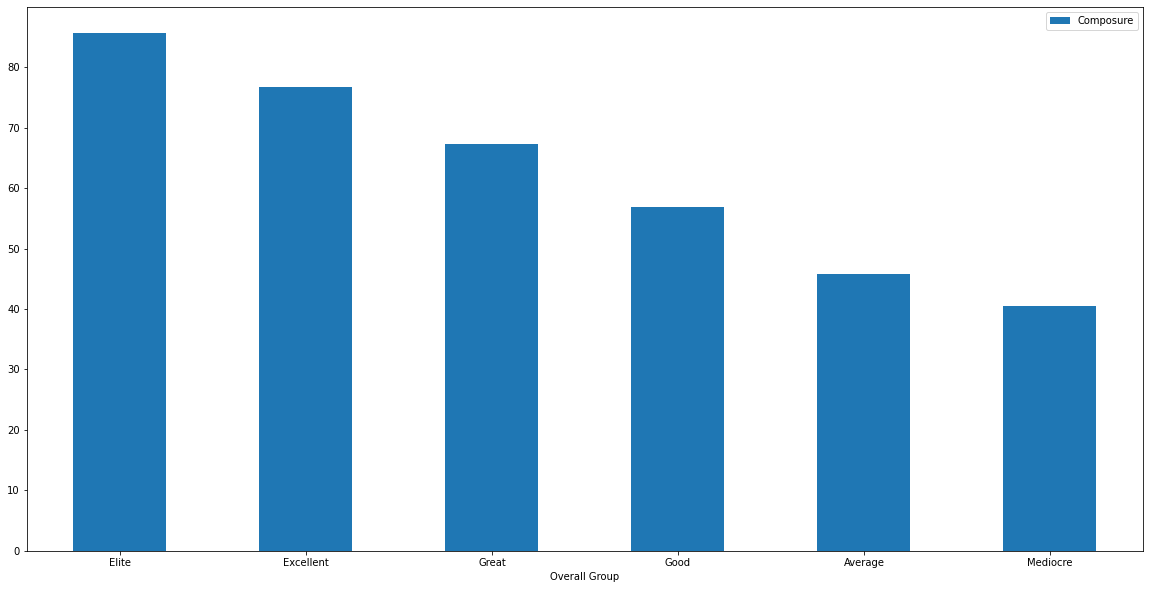

In [66]:
my_fifa.group_by_columns_and_agg(['Overall Group'], 'Composure', 'mean')
#yes

Conducting a mean on Marking for the group ['Overall Group']
----------------------------
                 Marking
Overall Group           
Excellent      57.835490
Great          53.001377
Elite          49.714286
Good           46.793491
Average        36.995382
Mediocre       34.168539
----------------------------



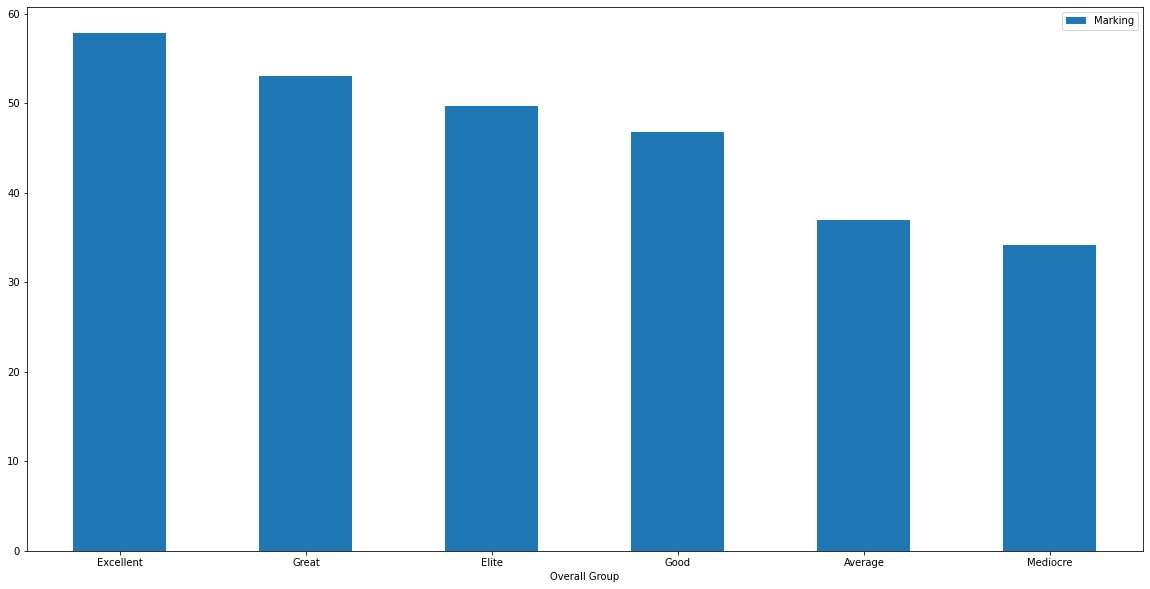

In [67]:
my_fifa.group_by_columns_and_agg(['Overall Group'], 'Marking', 'mean')
#no

Conducting a mean on StandingTackle for the group ['Overall Group']
----------------------------
               StandingTackle
Overall Group                
Excellent           56.818854
Great               53.400551
Elite               48.357143
Good                47.243007
Average             37.595027
Mediocre            35.146067
----------------------------



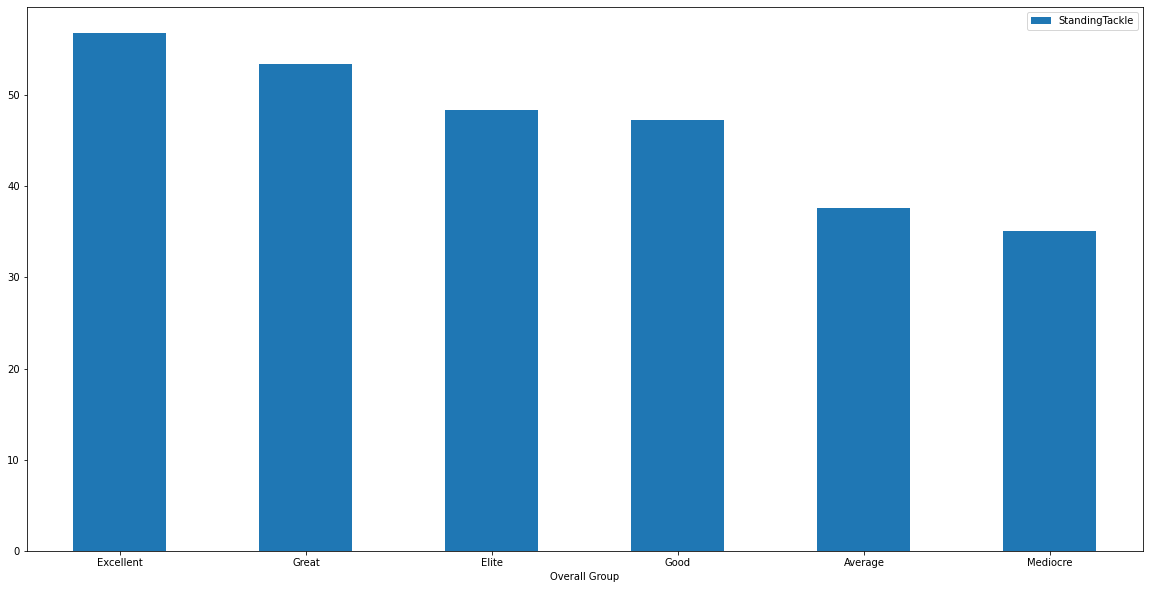

In [68]:
my_fifa.group_by_columns_and_agg(['Overall Group'], 'StandingTackle', 'mean')
#no

Conducting a mean on SlidingTackle for the group ['Overall Group']
----------------------------
               SlidingTackle
Overall Group               
Excellent          53.476895
Great              50.654928
Good               45.278569
Elite              42.428571
Average            36.759858
Mediocre           36.393258
----------------------------



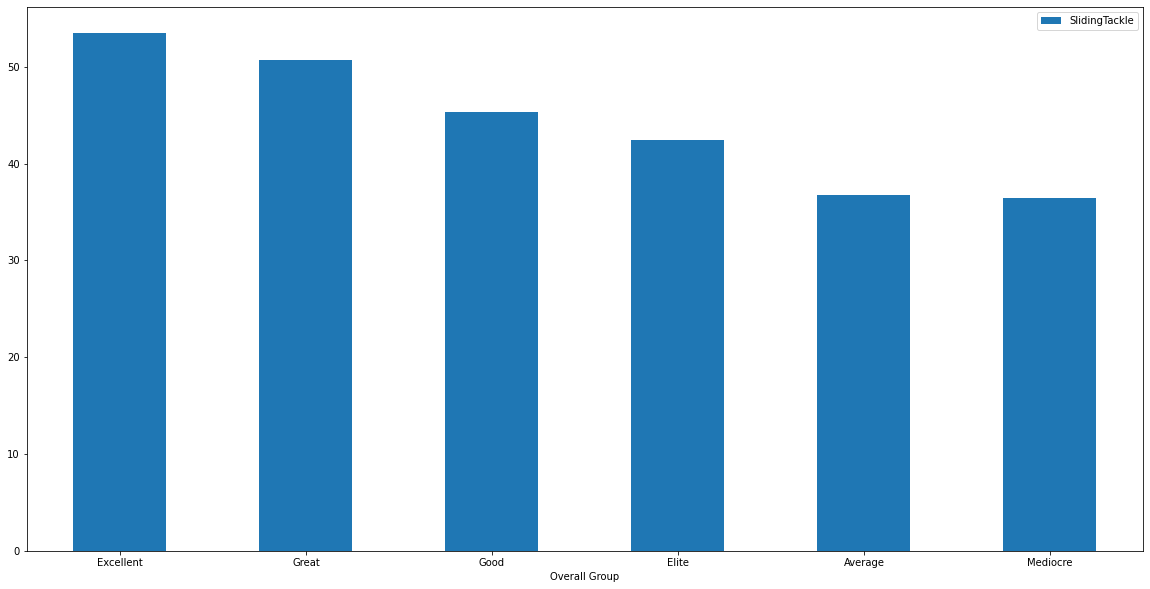

In [69]:
my_fifa.group_by_columns_and_agg(['Overall Group'], 'SlidingTackle', 'mean')
#no

Conducting a mean on GKDiving for the group ['Overall Group']
----------------------------
                GKDiving
Overall Group           
Elite          22.285714
Excellent      19.073937
Average        18.755595
Mediocre       17.235955
Good           16.142976
Great          16.038757
----------------------------



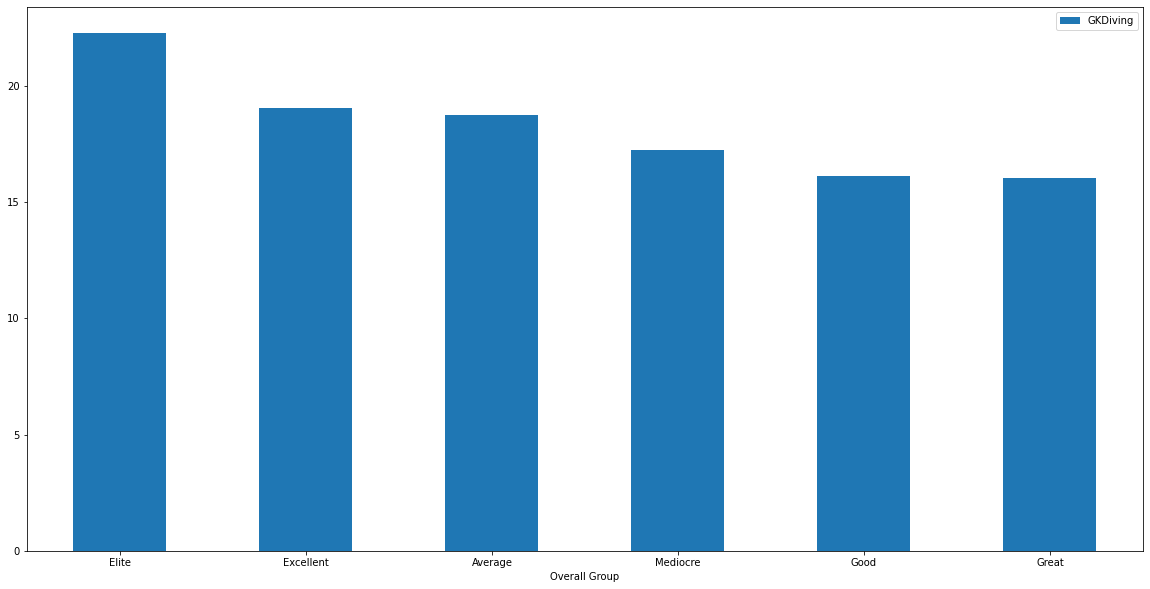

In [70]:
my_fifa.group_by_columns_and_agg(['Overall Group'], 'GKDiving', 'mean')
#no

Conducting a mean on GKHandling for the group ['Overall Group']
----------------------------
               GKHandling
Overall Group            
Elite           22.500000
Excellent       18.776340
Average         18.365542
Mediocre        17.224719
Good            15.951024
Great           15.846744
----------------------------



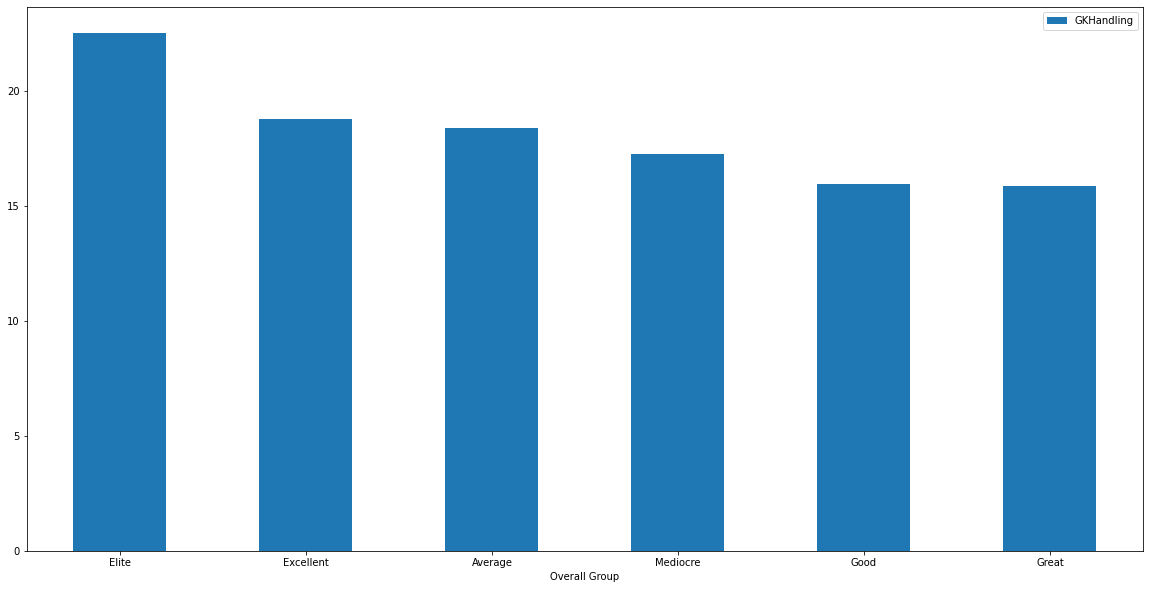

In [71]:
my_fifa.group_by_columns_and_agg(['Overall Group'], 'GKHandling', 'mean')
#no

Conducting a mean on GKPositioning for the group ['Overall Group']
----------------------------
               GKPositioning
Overall Group               
Elite              22.642857
Excellent          18.658041
Average            18.060746
Mediocre           16.606742
Good               15.990850
Great              15.953571
----------------------------



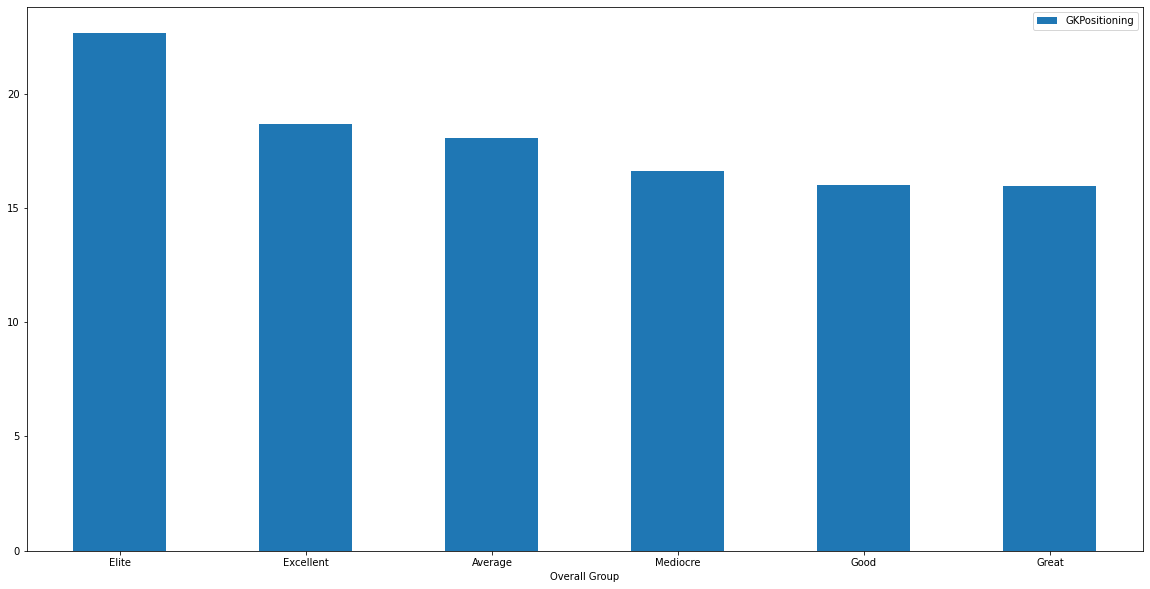

In [72]:
my_fifa.group_by_columns_and_agg(['Overall Group'], 'GKPositioning', 'mean')
#no

Conducting a mean on GKReflexes for the group ['Overall Group']
----------------------------
               GKReflexes
Overall Group            
Elite           24.142857
Excellent       19.121996
Average         18.668561
Mediocre        16.651685
Good            16.304565
Great           16.119418
----------------------------



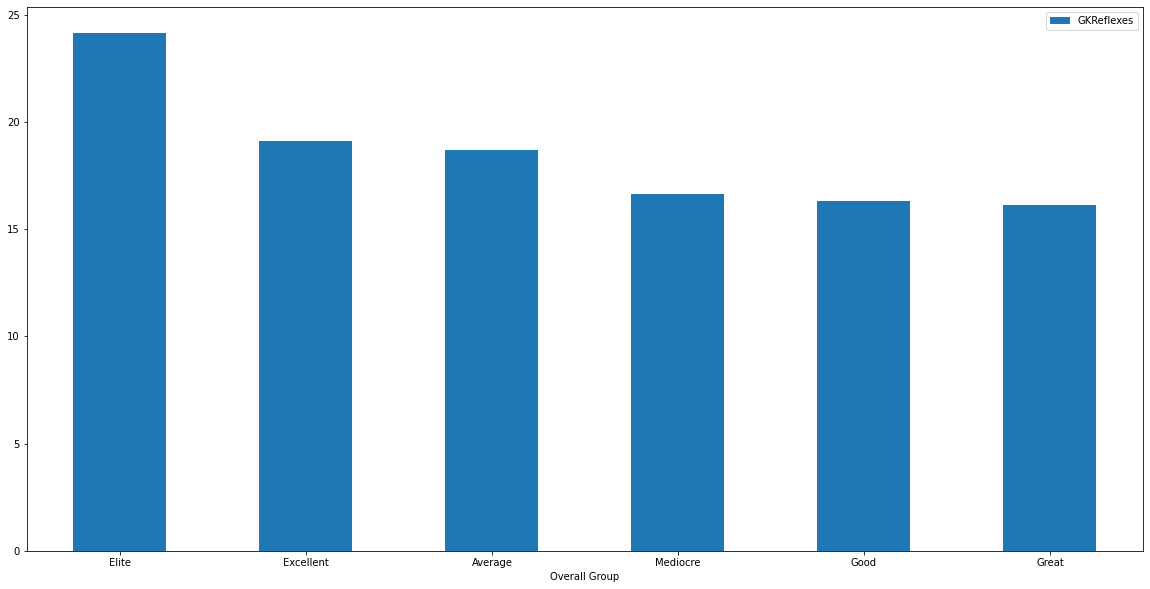

In [73]:
my_fifa.group_by_columns_and_agg(['Overall Group'], 'GKReflexes', 'mean')
#no